# Thread 2: Gender Injustice

### This thread looks at the crimes against women in the past decade and concludes important pointers from it. For ex- how the rate of crime against women is affected each year, whether criminals are convicted, etc.

## Analysis

# Importing Libraries

In [46]:
import sys
sys.path.append("..")
import utility as u
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
importlib.reload(u)

<module 'utility' from '/Users/bhavya/Documents/DS/The Committee Will Look Into It/02_Gender_Injustice/../utility.py'>

## Loading Data files

In [47]:
csv1= u.load_data("data/cleaned/file1.csv")
csv2= u.load_data("data/cleaned/file2.csv")
csv3= u.load_data("data/cleaned/file3.csv")
csv4= u.load_data("data/cleaned/file4.csv")
csv5= u.load_data("data/cleaned/file5.csv")
csv6= u.load_data("data/cleaned/file6.csv")
csv7= u.load_data("data/cleaned/file7.csv")

## a. csv1 Analysis

In [48]:
csv1.columns

Index(['CRIME HEAD', 'year', 'cases'], dtype='object')

Chart saved- charts/csv1_01_multiline_crime_heads.png


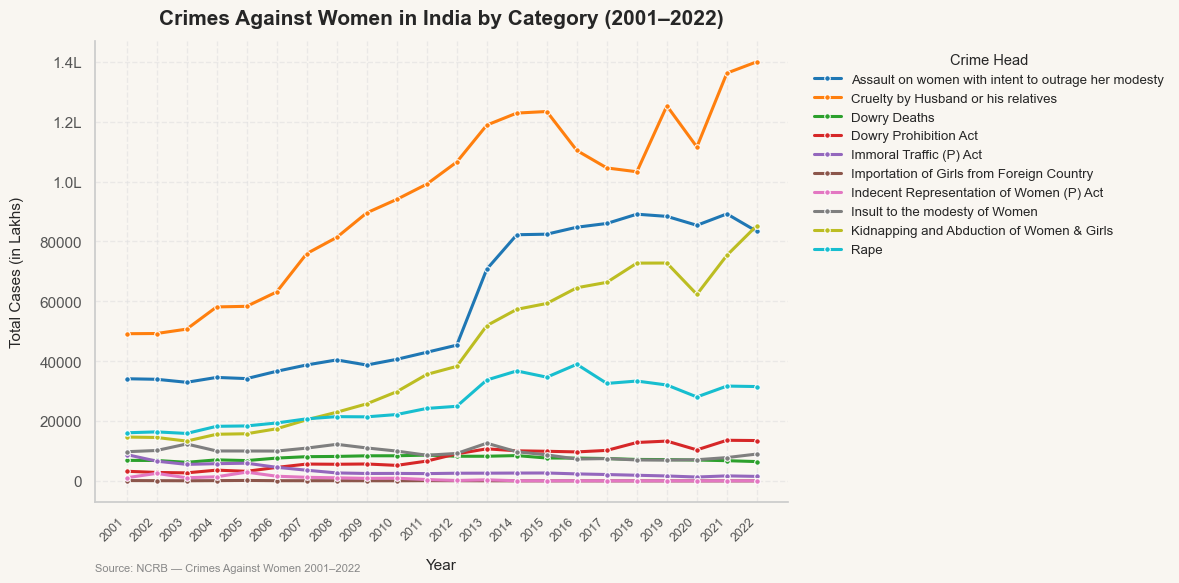

In [49]:
crime_by_year = csv1.groupby(["year", "CRIME HEAD"])["cases"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.lineplot(
    data=crime_by_year,
    x="year",
    y="cases",
    hue="CRIME HEAD",
    palette="tab10",
    linewidth=2.2,
    marker="o",
    markersize=4,
    ax=ax,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))

ax.set_xticks(crime_by_year["year"].unique())
ax.set_xticklabels(
    crime_by_year["year"].unique(), rotation=45, ha="right", fontsize=9
)

ax.legend(
    title="Crime Head",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5,
)

ax.set_title(
    "Crimes Against Women in India by Category (2001–2022)",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total Cases (in Lakhs)", fontsize=11)

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_01_multiline_crime_heads.png")
plt.show()

Chart saved- charts/csv1_02_stacked_area_composition.png


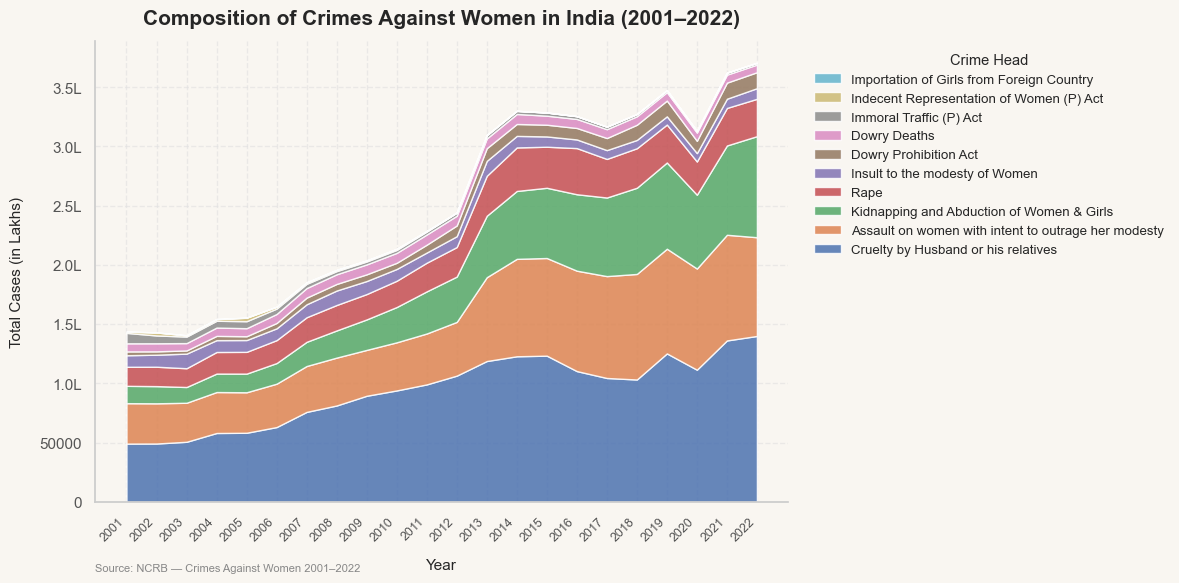

In [50]:
pivot_df = csv1.pivot_table(
    index="year", columns='CRIME HEAD', values="cases", aggfunc="sum"
).fillna(0)

column_order = pivot_df.sum().sort_values(ascending=False).index
pivot_df = pivot_df[column_order]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

ax.stackplot(
    pivot_df.index,
    pivot_df.T,
    labels=pivot_df.columns,
    alpha=0.85,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))

ax.set_xticks(pivot_df.index)
ax.set_xticklabels(pivot_df.index, rotation=45, ha="right", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Crime Head",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5,
)

ax.set_title(
    "Composition of Crimes Against Women in India (2001–2022)",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total Cases (in Lakhs)", fontsize=11)

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_02_stacked_area_composition.png")
plt.show()

Chart saved- charts/csv1_03_total_crimes_annotated.png


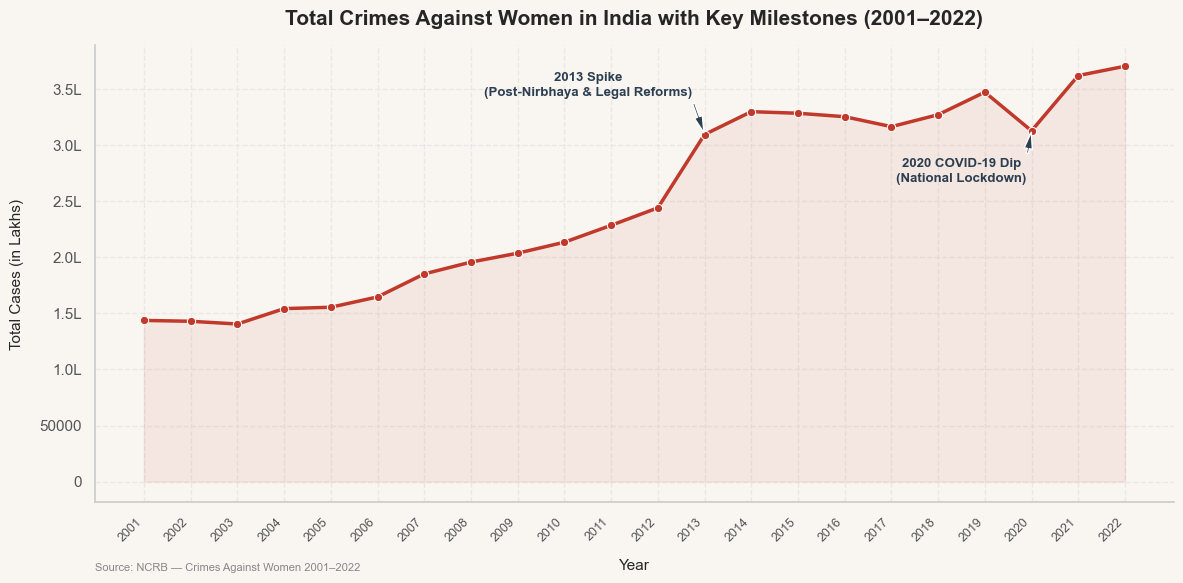

In [51]:
total_per_year = csv1.groupby("year")["cases"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.lineplot(
    data=total_per_year,
    x="year",
    y="cases",
    color="#c0392b",
    linewidth=2.5,
    marker="o",
    markersize=6,
    ax=ax,
)

ax.fill_between(
    total_per_year["year"],
    total_per_year["cases"],
    alpha=0.08,
    color="#c0392b",
)

# 2013 Spike (Post-Nirbhaya & Criminal Law Amendment Act)
val_2013 = total_per_year.loc[total_per_year["year"] == 2013, "cases"].values[0]
ax.annotate(
    "2013 Spike\n(Post-Nirbhaya & Legal Reforms)",
    xy=(2013, val_2013),
    xytext=(2010.5, val_2013 + 35000),
    arrowprops=dict(facecolor="#2c3e50", shrink=0.05, width=1.5, headwidth=6),
    fontsize=9.5,
    fontweight="bold",
    color="#2c3e50",
    ha="center",
)

# 2020 Dip (COVID-19 Lockdowns)
val_2020 = total_per_year.loc[total_per_year["year"] == 2020, "cases"].values[0]
ax.annotate(
    "2020 COVID-19 Dip\n(National Lockdown)",
    xy=(2020, val_2020),
    xytext=(2018.5, val_2020 - 45000),
    arrowprops=dict(facecolor="#2c3e50", shrink=0.05, width=1.5, headwidth=6),
    fontsize=9.5,
    fontweight="bold",
    color="#2c3e50",
    ha="center",
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))
ax.set_xticks(total_per_year["year"])
ax.set_xticklabels(total_per_year["year"], rotation=45, ha="right", fontsize=9)

ax.set_title(
    "Total Crimes Against Women in India with Key Milestones (2001–2022)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total Cases (in Lakhs)", fontsize=11)

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_03_total_crimes_annotated.png")
plt.show()

Chart saved- charts/csv1_04_pct_change_bar_chart.png


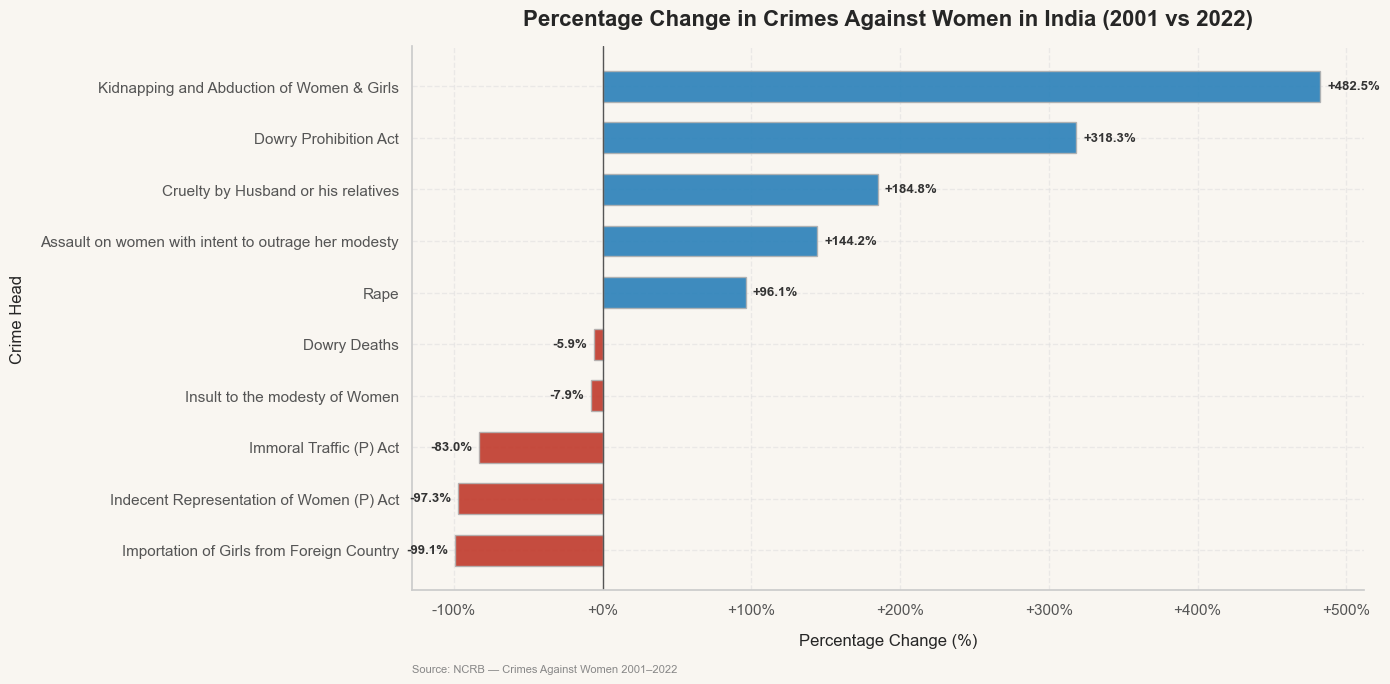

In [52]:
u.set_style()


# Calculate percentage change from 2001 to 2022 per crime head
csv1_2001 = csv1[csv1["year"] == 2001].set_index("CRIME HEAD")["cases"]
csv1_2022 = csv1[csv1["year"] == 2022].set_index("CRIME HEAD")["cases"]

pct_change = ((csv1_2022 - csv1_2001) / csv1_2001 * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#c0392b" if x < 0 else "#2980b9" for x in pct_change.values]
bars = ax.barh(
    pct_change.index,
    pct_change.values,
    color=colors,
    height=0.6,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Percentage Change in Crimes Against Women in India (2001 vs 2022)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Percentage Change (%)", fontsize=12)
ax.set_ylabel("Crime Head", fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:+.0f}%")
)
ax.axvline(0, color="#555555", linestyle="-", linewidth=1)

for bar in bars:
  width = bar.get_width()
  ha = "left" if width >= 0 else "right"
  offset = 5 if width >= 0 else -5
  ax.annotate(
      f"{width:+.1f}%",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(offset, 0),
      textcoords="offset points",
      ha=ha,
      va="center",
      fontsize=9.5,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crimes Against Women 2001–2022")

plt.tight_layout()
u.save_fig(fig, "charts", "csv1_04_pct_change_bar_chart.png")
plt.show()

## b. csv2 Analysis

In [53]:
csv2.columns

Index(['Year', 'State_UT', 'Is_Detailed_Subcategory', 'Count',
       'Crime_Head_Standardized', 'Crime_Head_Subcategory'],
      dtype='object')

Chart saved- charts/csv2_01_state_crimes_bar_2022.png


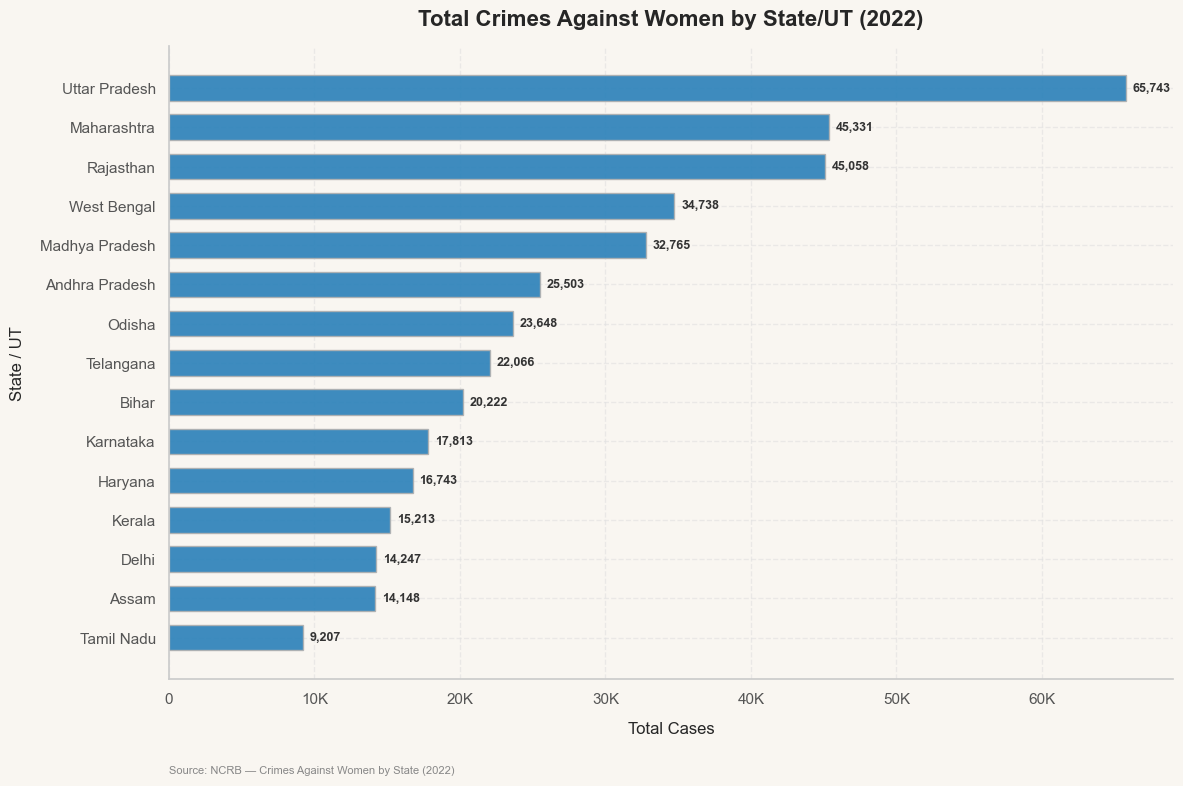

In [54]:
u.set_style()

csv2_2022 = csv2[csv2["Year"] == 2022]

state_totals = csv2_2022.groupby("State_UT")["Count"].sum().sort_values(ascending=True)
top_states = state_totals.tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    top_states.index,
    top_states.values,
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Crimes Against Women by State/UT (2022)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Cases", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:,.0f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crimes Against Women by State (2022)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_01_state_crimes_bar_2022.png")
plt.show()

Chart saved- charts/csv2_02_state_crimes_bar_2020.png


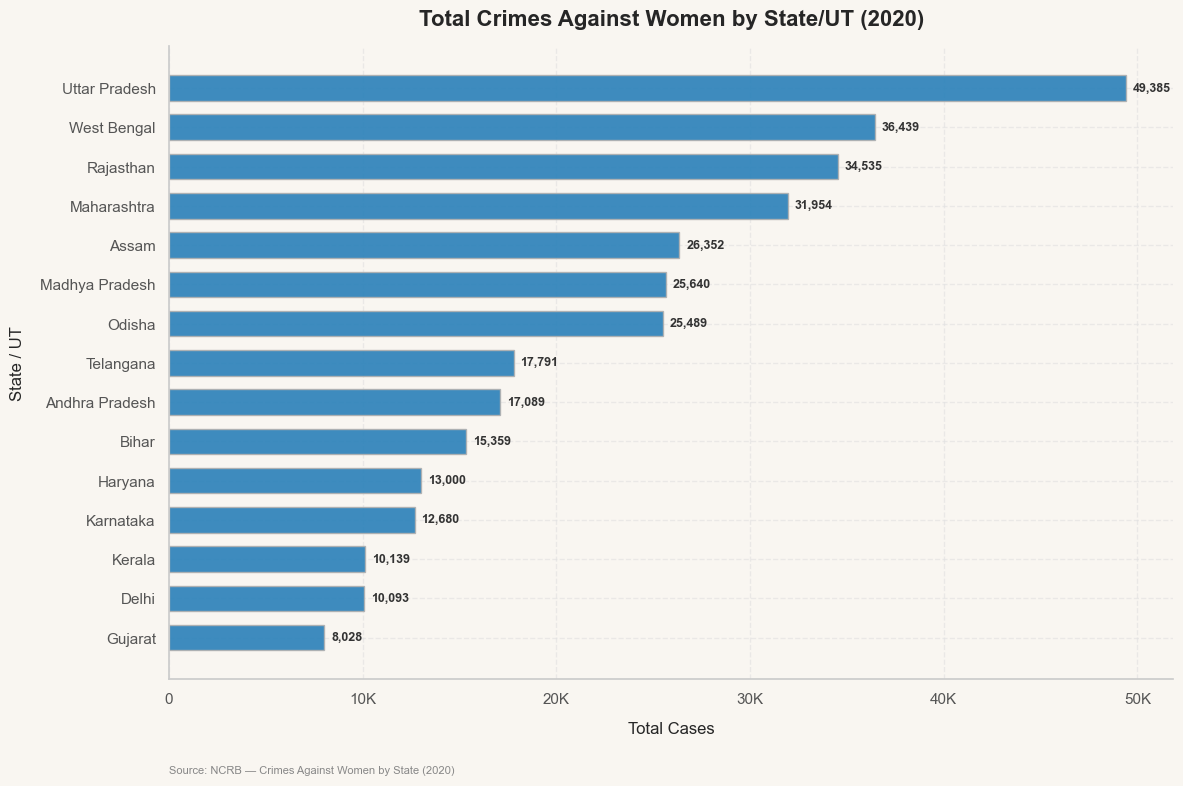

In [55]:
u.set_style()

csv2_2020 = csv2[csv2["Year"] == 2020]

state_totals = csv2_2020.groupby("State_UT")["Count"].sum().sort_values(ascending=True)
top_states = state_totals.tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    top_states.index,
    top_states.values,
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Crimes Against Women by State/UT (2020)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Cases", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:,.0f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crimes Against Women by State (2020)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_02_state_crimes_bar_2020.png")
plt.show()

Chart saved- charts/csv2_03_state_crimes_bar_2001.png


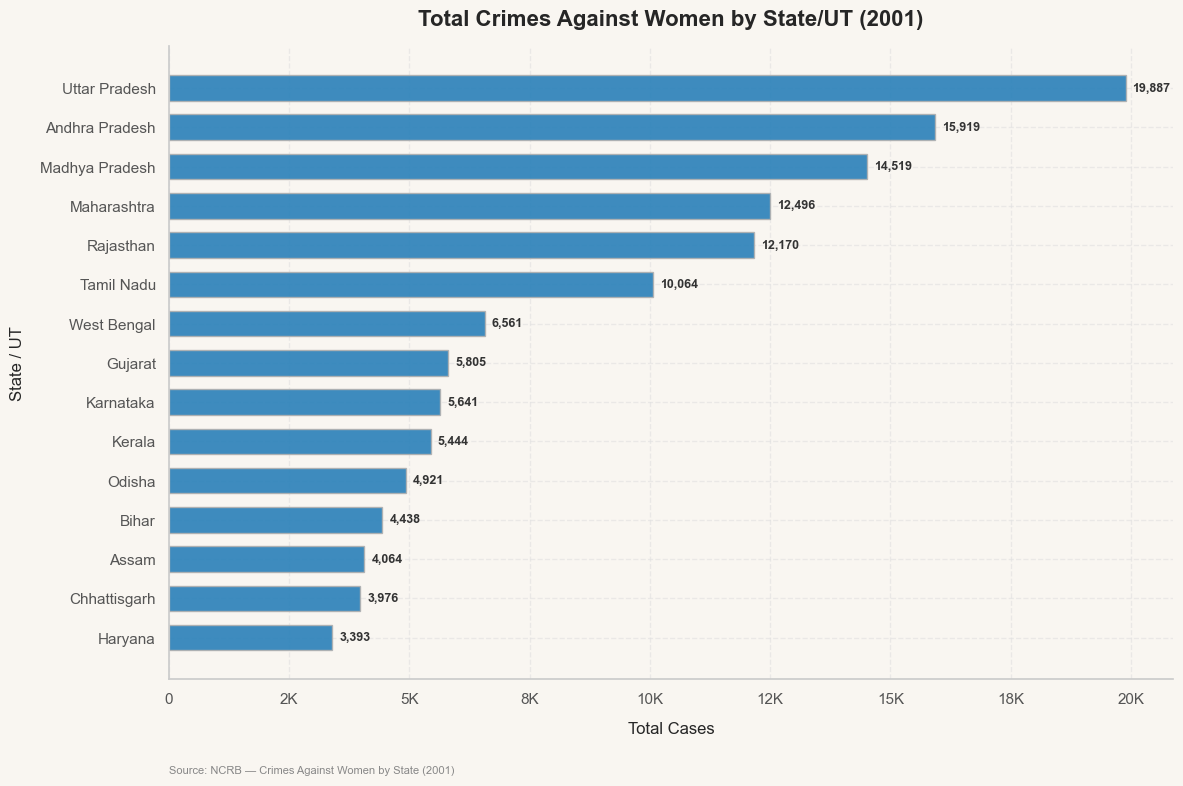

In [56]:
u.set_style()

csv2_2001 = csv2[csv2["Year"] == 2001]

state_totals = csv2_2001.groupby("State_UT")["Count"].sum().sort_values(ascending=True)
top_states = state_totals.tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    top_states.index,
    top_states.values,
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Crimes Against Women by State/UT (2001)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Cases", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:,.0f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crimes Against Women by State (2001)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_03_state_crimes_bar_2001.png")
plt.show()

Chart saved- charts/csv2_04_state_crime_heatmap_standardized_2014.png


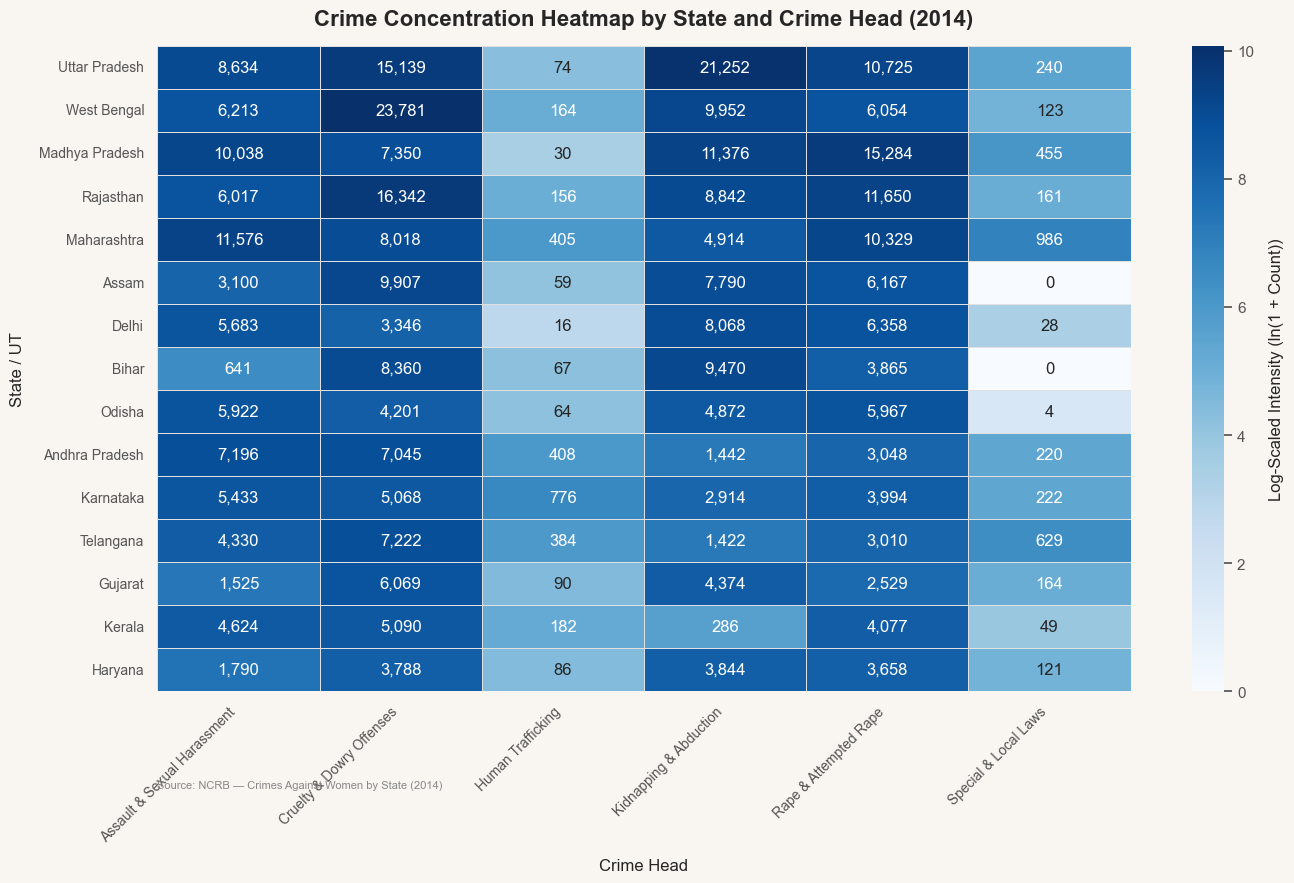

In [57]:
csv2_2014 = csv2[csv2["Year"] == 2014]

pivot_df = csv2_2014.pivot_table(
    index="State_UT", columns="Crime_Head_Standardized", values="Count", aggfunc="sum"
).fillna(0)

state_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
top_states = state_totals.head(15).index
pivot_top = pivot_df.loc[top_states]

# Apply log scaling for the heatmap values (using log1p to safely handle zero values)
log_pivot = np.log1p(pivot_top)

u.set_style()

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.heatmap(
    log_pivot,
    cmap="Blues",
    annot=pivot_top,
    fmt=",.0f",
    linewidths=0.5,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Log-Scaled Intensity (ln(1 + Count))"},
    ax=ax,
)

ax.set_title(
    "Crime Concentration Heatmap by State and Crime Head (2014)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Crime Head", fontsize=12, labelpad=10)
ax.set_ylabel("State / UT", fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

u.add_source(ax, "NCRB — Crimes Against Women by State (2014)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_04_state_crime_heatmap_standardized_2014.png")
plt.show()

Chart saved- charts/csv2_05_state_crime_heatmap_subcategory_2014.png


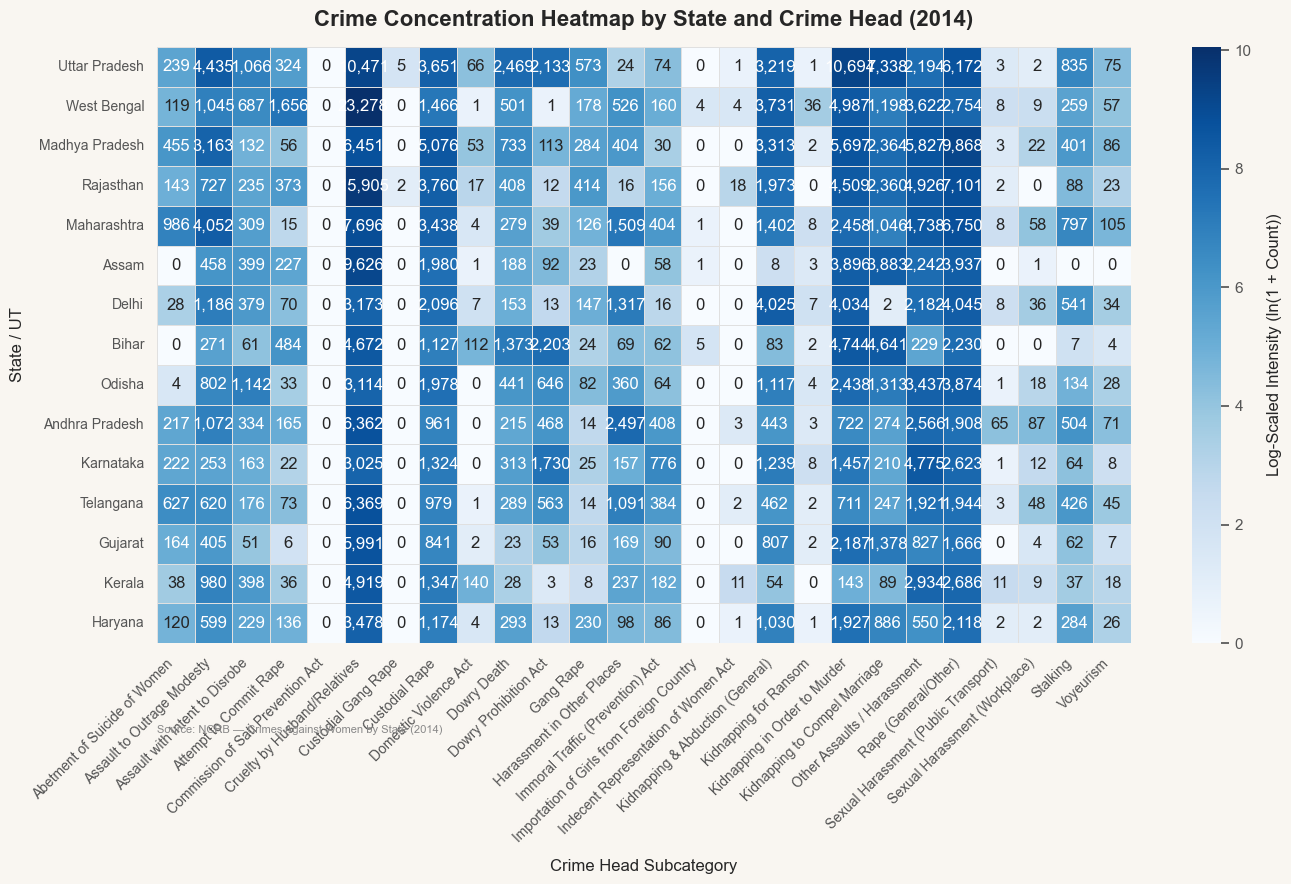

In [58]:
csv2_2014 = csv2[csv2["Year"] == 2014]

pivot_df = csv2_2014.pivot_table(
    index="State_UT", columns="Crime_Head_Subcategory", values="Count", aggfunc="sum"
).fillna(0)

state_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
top_states = state_totals.head(15).index
pivot_top = pivot_df.loc[top_states]

# Apply log scaling for the heatmap values (using log1p to safely handle zero values)
log_pivot = np.log1p(pivot_top)

u.set_style()

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.heatmap(
    log_pivot,
    cmap="Blues",
    annot=pivot_top,
    fmt=",.0f",
    linewidths=0.5,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Log-Scaled Intensity (ln(1 + Count))"},
    ax=ax,
)

ax.set_title(
    "Crime Concentration Heatmap by State and Crime Head (2014)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Crime Head Subcategory", fontsize=12, labelpad=10)
ax.set_ylabel("State / UT", fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

u.add_source(ax, "NCRB — Crimes Against Women by State (2014)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_05_state_crime_heatmap_subcategory_2014.png")
plt.show()

/var/folders/p_/8l92psx106q_nhcpkf5_sthw0000gn/T/ipykernel_49829/3528537985.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  csv2_2014['Crime_Category_full']= (csv2_2014["Crime_Head_Standardized"] + " — " + csv2_2014["Crime_Head_Subcategory"])


Chart saved- charts/csv2_06_state_crime_heatmap_detailed_2014.png


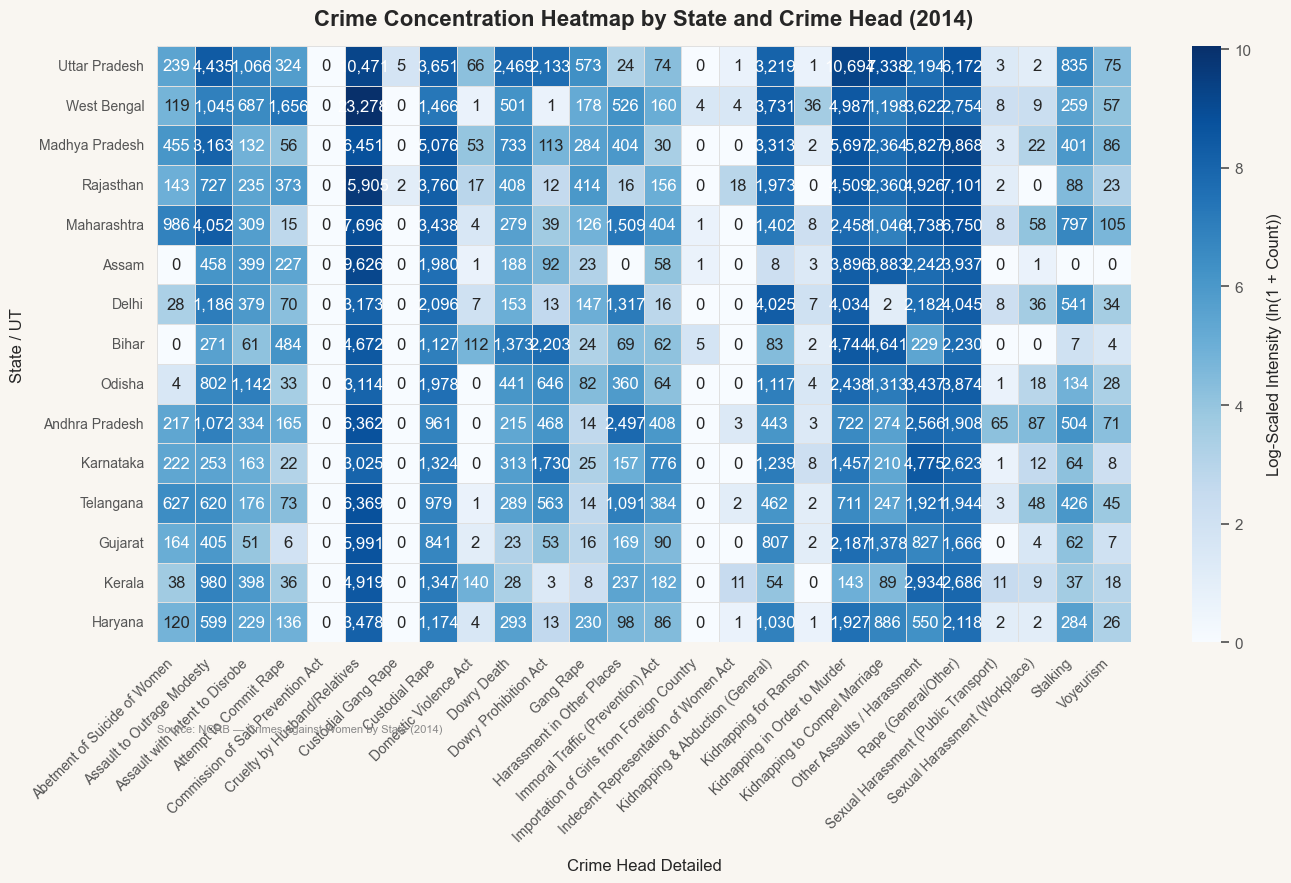

In [59]:
csv2_2014 = csv2[csv2["Year"] == 2014]
csv2_2014['Crime_Category_full']= (csv2_2014["Crime_Head_Standardized"] + " — " + csv2_2014["Crime_Head_Subcategory"])

pivot_df = csv2_2014.pivot_table(
    index="State_UT", columns="Crime_Head_Subcategory", values="Count", aggfunc="sum"
).fillna(0)

state_totals = pivot_df.sum(axis=1).sort_values(ascending=False)
top_states = state_totals.head(15).index
pivot_top = pivot_df.loc[top_states]

# Apply log scaling for the heatmap values (using log1p to safely handle zero values)
log_pivot = np.log1p(pivot_top)

u.set_style()

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

sns.heatmap(
    log_pivot,
    cmap="Blues",
    annot=pivot_top,
    fmt=",.0f",
    linewidths=0.5,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Log-Scaled Intensity (ln(1 + Count))"},
    ax=ax,
)

ax.set_title(
    "Crime Concentration Heatmap by State and Crime Head (2014)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Crime Head Detailed", fontsize=12, labelpad=10)
ax.set_ylabel("State / UT", fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

u.add_source(ax, "NCRB — Crimes Against Women by State (2014)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_06_state_crime_heatmap_detailed_2014.png")
plt.show()

Chart saved- charts/csv2_07_top5_states_trend_grid.png


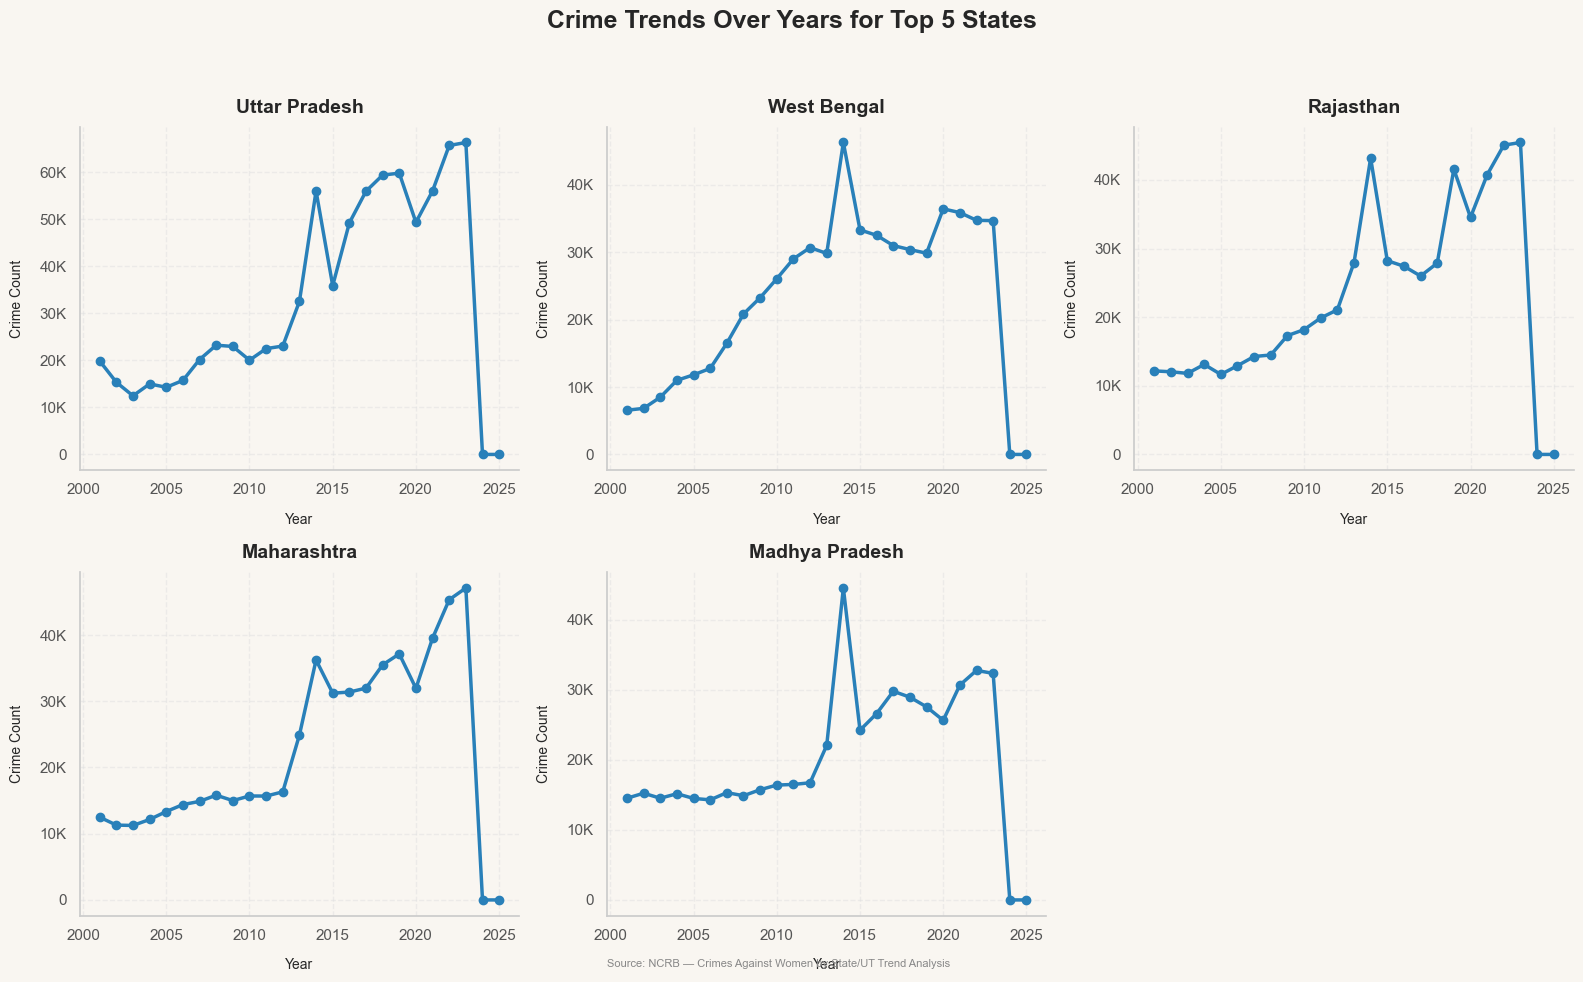

In [60]:
u.set_style()

state_totals = csv2.groupby("State_UT")["Count"].sum()
top_5_states = state_totals.nlargest(5).index.tolist()

df_top5 = csv2[csv2["State_UT"].isin(top_5_states)]
trend_data = (
    df_top5.groupby(["Year", "State_UT"])["Count"].sum().unstack(fill_value=0)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False)
fig.patch.set_facecolor(u.BG_COLOR)
axes = axes.flatten()

for i, state in enumerate(top_5_states):
  ax = axes[i]
  ax.set_facecolor(u.BG_COLOR)
  ax.plot(
      trend_data.index,
      trend_data[state],
      marker="o",
      linewidth=2.5,
      color="#2980b9",
      markersize=6,
  )
  ax.set_title(state, fontsize=14, fontweight="bold", pad=10)
  ax.set_xlabel("Year", fontsize=10)
  ax.set_ylabel("Crime Count", fontsize=10)
  ax.grid(True, linestyle="--", alpha=0.5)
  ax.yaxis.set_major_formatter(
      plt.FuncFormatter(
          lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
      )
  )

for j in range(len(top_5_states), len(axes)):
  fig.delaxes(axes[j])

fig.suptitle(
    "Crime Trends Over Years for Top 5 States",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)
u.add_source(
    axes[-2], "NCRB — Crimes Against Women by State/UT Trend Analysis"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
u.save_fig(fig, "charts", "csv2_07_top5_states_trend_grid.png")
plt.show()

Chart saved- charts/csv2_08_all_india_vs_states_line.png


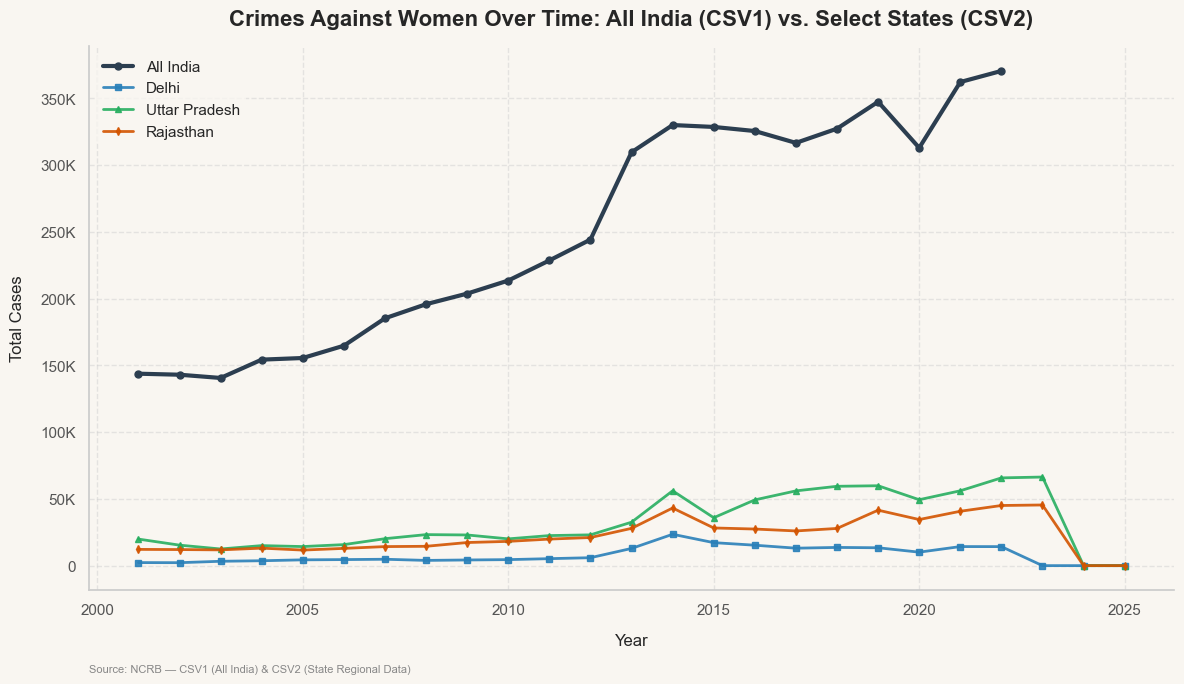

In [61]:
u.set_style()

all_india = csv1.groupby("year")["cases"].sum().reset_index()
all_india.rename(columns={"year": "Year", "cases": "Count"}, inplace=True)

focus_states = ["Delhi", "Uttar Pradesh", "Rajasthan"]
states_df = (
    csv2[csv2["State_UT"].isin(focus_states)]
    .groupby(["Year", "State_UT"])["Count"]
    .sum()
    .reset_index()
)
states_df.rename(columns={"State_UT": "Region"}, inplace=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

ax.plot(
    all_india["Year"],
    all_india["Count"],
    label="All India",
    color="#2c3e50",
    linewidth=3.0,
    marker="o",
    markersize=5,
)

colors = {"Delhi": "#2980b9", "Uttar Pradesh": "#27ae60", "Rajasthan": "#d35400"}
markers = {"Delhi": "s", "Uttar Pradesh": "^", "Rajasthan": "d"}

for state in focus_states:
  state_data = states_df[states_df["Region"] == state].sort_values("Year")
  ax.plot(
      state_data["Year"],
      state_data["Count"],
      label=state,
      color=colors.get(state, "#333333"),
      linewidth=2.0,
      marker=markers.get(state, "o"),
      markersize=4,
      alpha=0.9,
  )

ax.set_title(
    "Crimes Against Women Over Time: All India (CSV1) vs. Select States (CSV2)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Cases", fontsize=12)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

ax.legend(
    frameon=True, facecolor=u.BG_COLOR, edgecolor="none", fontsize=11, loc="upper left"
)
ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(ax, "NCRB — CSV1 (All India) & CSV2 (State Regional Data)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv2_08_all_india_vs_states_line.png")
plt.show()

Chart saved- charts/csv2_09_state_bar_2022_with_delta.png


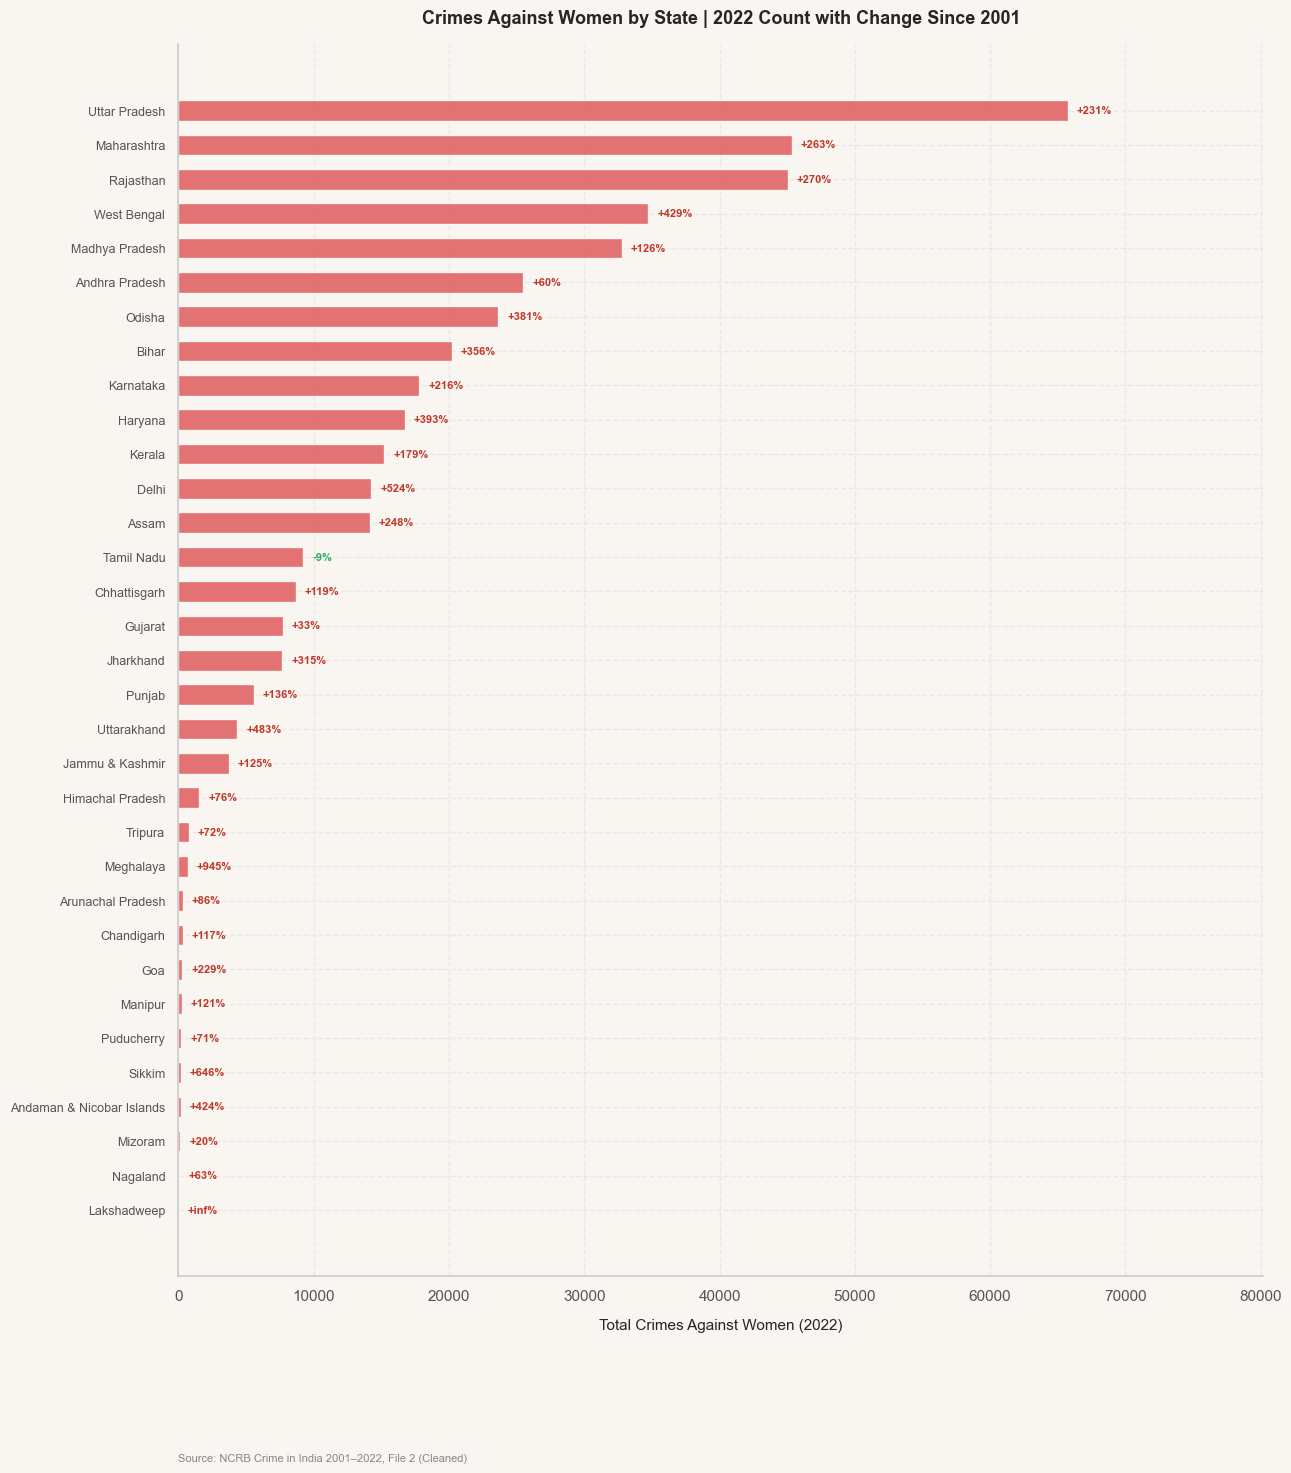

In [62]:
# Drop subcategory rows to avoid double-counting
states = csv2[csv2["Is_Detailed_Subcategory"] == False].copy()

# Drop stray 2023+ zero rows
states = states[states["Year"].astype(int) <= 2022]

# Total crimes per state per year, for 2001 and 2022 only
state_totals = (
    states[states["Year"].astype(int).isin([2001, 2022])]
    .groupby(["State_UT", "Year"])["Count"]
    .sum()
    .reset_index()
)
state_totals["Year"] = state_totals["Year"].astype(int)

pivot_s = (
    state_totals.pivot(index="State_UT", columns="Year", values="Count")
    .dropna()
    .sort_values(2022, ascending=True)   # ascending for horizontal bar readability
)

pivot_s["delta_pct"] = ((pivot_s[2022] - pivot_s[2001]) / pivot_s[2001]) * 100

u.set_style()
fig, ax = plt.subplots(figsize=(14, 16))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y_pos = range(len(pivot_s))
bars = ax.barh(
    list(y_pos),
    pivot_s[2022],
    color="#e05c5c",
    alpha=0.85,
    height=0.6,
)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(pivot_s.index, fontsize=9)
ax.set_xlabel("Total Crimes Against Women (2022)", fontsize=11)
ax.set_title(
    "Crimes Against Women by State | 2022 Count with Change Since 2001",
    fontsize=13, fontweight="bold", pad=15
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))

# Delta labels — placed just after bar end
x_max = pivot_s[2022].max()
for i, (_, row) in enumerate(pivot_s.iterrows()):
    delta = row["delta_pct"]
    sign  = "+" if delta >= 0 else ""
    color = "#c0392b" if delta >= 0 else "#27ae60"
    ax.text(
        row[2022] + x_max * 0.01,   # small offset from bar tip
        i,
        f"{sign}{delta:.0f}%",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold",
        color=color,
    )

# Extra right margin so delta labels don't get clipped
ax.set_xlim(right=x_max * 1.22)

u.add_source(ax, "NCRB Crime in India 2001–2022, File 2 (Cleaned)")
u.save_fig(fig, "charts", "csv2_09_state_bar_2022_with_delta.png")
plt.show()

## c. csv3 Analysis

In [63]:
csv3.columns

Index(['State/UT', 'Pending Cases (2022)', 'Cases Sent for Trial (2023)',
       'Cases Abated', 'Cases Withdrawn', 'Cases Compounded', 'Plea Bargained',
       'Cases Quashed', 'Cases Stayed/Record Room', 'Convictions (2022)',
       'Convictions (2023)', 'Cases Discharged', 'Cases Acquitted',
       'Conviction Rate (%)', 'Pendency Percentage (%)'],
      dtype='object')

Chart saved- charts/csv3_01_conviction_rate_bargraph.png


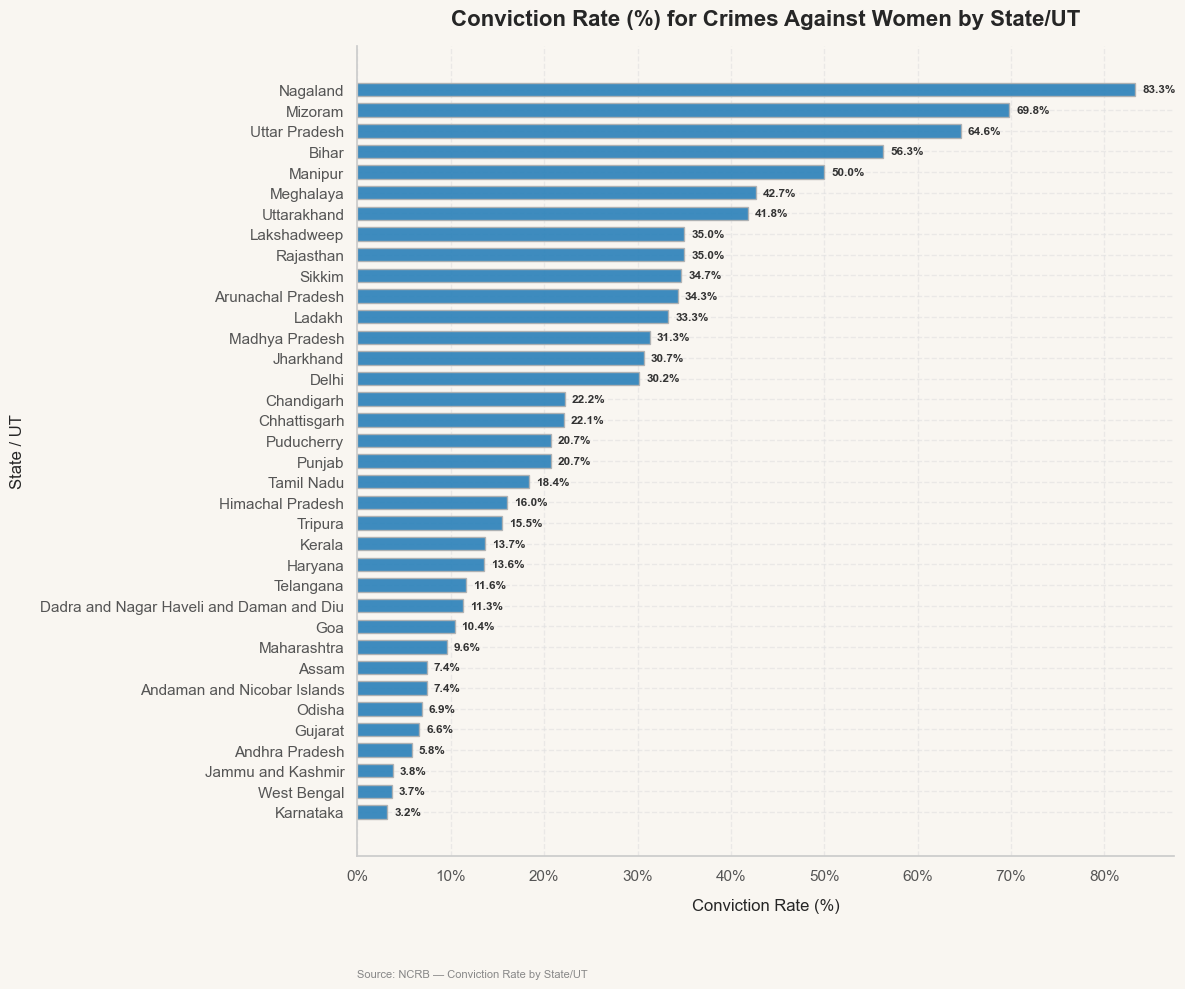

In [64]:
u.set_style()

csv3 = csv3.sort_values(by="Conviction Rate (%)", ascending=True)

# Initialize figure
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    csv3["State/UT"],
    csv3["Conviction Rate (%)"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Conviction Rate (%) for Crimes Against Women by State/UT",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Conviction Rate (%)", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0f}%"))

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:.1f}%",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=8.5,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Conviction Rate by State/UT")

plt.tight_layout()
u.save_fig(fig, "charts", "csv3_01_conviction_rate_bargraph.png")
plt.show()

Chart saved- charts/csv3_02_pendency_pct_bargraph.png


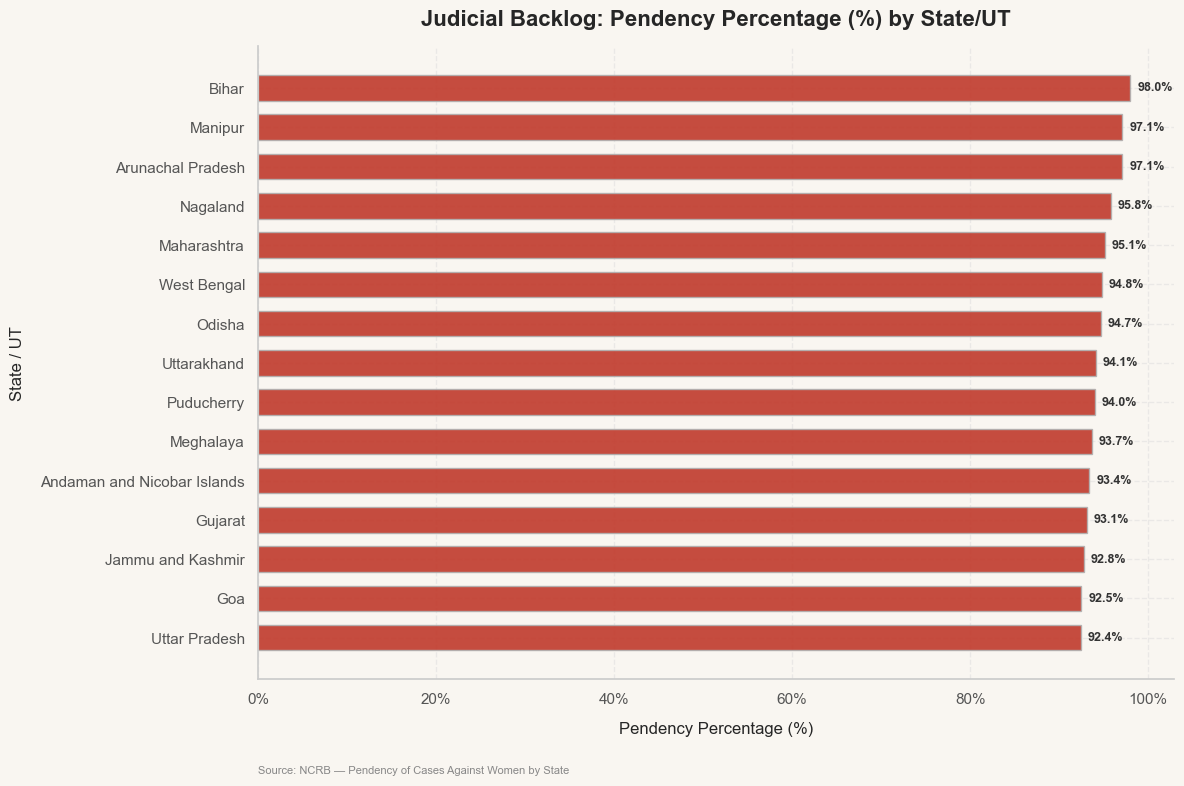

In [65]:
u.set_style()

# Sort by Pendency Percentage (%) to get top 15 states with highest backlog
top_pendency = csv3.sort_values(
    by="Pendency Percentage (%)", ascending=True
).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    top_pendency["State/UT"],
    top_pendency["Pendency Percentage (%)"],
    color="#c0392b",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Judicial Backlog: Pendency Percentage (%) by State/UT",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Pendency Percentage (%)", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0f}%"))

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:.1f}%",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Pendency of Cases Against Women by State")

plt.tight_layout()
u.save_fig(fig, "charts", "csv3_02_pendency_pct_bargraph.png")
plt.show()

Chart saved- charts/csv3_03_conviction_vs_pendency_scatterplot.png


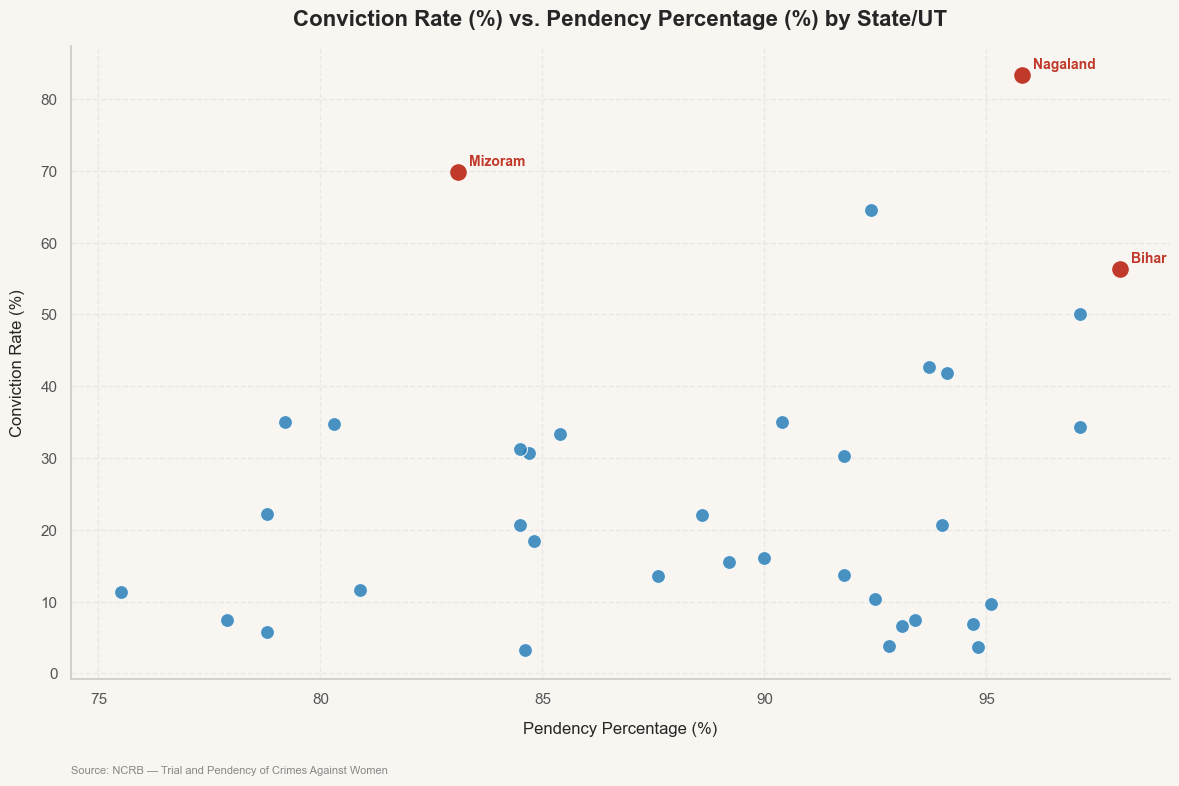

In [66]:
u.set_style()

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

# Scatter plot for Conviction Rate vs Pendency Percentage
sns.scatterplot(
    data=csv3,
    x="Pendency Percentage (%)",
    y="Conviction Rate (%)",
    color="#2980b9",
    s=100,
    alpha=0.85,
    ax=ax,
)

ax.set_title(
    "Conviction Rate (%) vs. Pendency Percentage (%) by State/UT",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Pendency Percentage (%)", fontsize=12)
ax.set_ylabel("Conviction Rate (%)", fontsize=12)

# Annotate and highlight specified outliers (Bihar, Nagaland, Mizoram)
outliers = ["Bihar", "Nagaland", "Mizoram"]
for _, row in csv3[csv3["State/UT"].isin(outliers)].iterrows():
  ax.annotate(
      row["State/UT"],
      xy=(row["Pendency Percentage (%)"], row["Conviction Rate (%)"]),
      xytext=(8, 5),
      textcoords="offset points",
      fontsize=10,
      fontweight="bold",
      color="#c0392b",
  )
  ax.scatter(
      row["Pendency Percentage (%)"],
      row["Conviction Rate (%)"],
      color="#c0392b",
      s=120,
      zorder=5,
  )

u.add_source(
    ax, "NCRB — Trial and Pendency of Crimes Against Women"
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv3_03_conviction_vs_pendency_scatterplot.png")
plt.show()

Chart saved- charts/csv3_case_disposition_stacked_bar.png


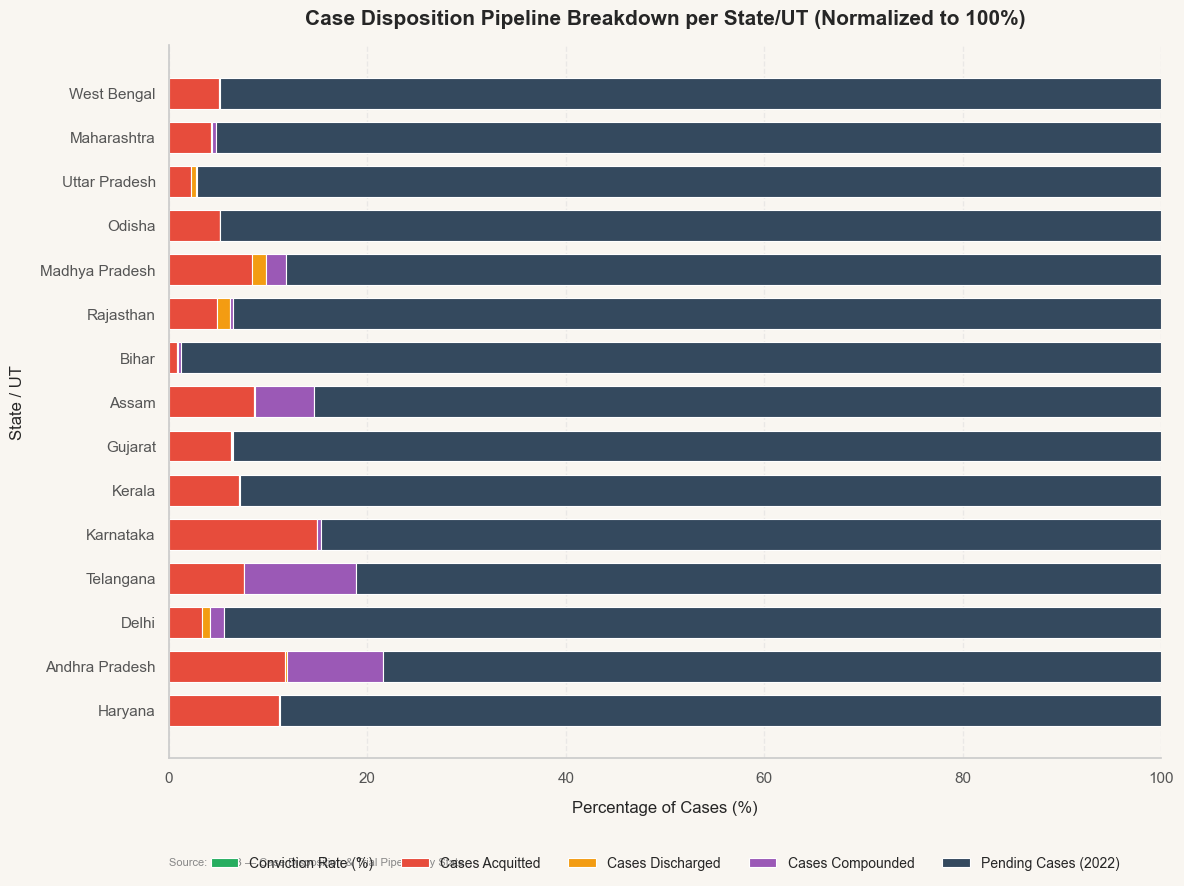

In [67]:
csv3

col_map = {}
for col in csv3.columns:
  col_lower = col.lower()
  if "convict" in col_lower:
    col_map["Convicted"] = col
  elif "acquit" in col_lower:
    col_map["Acquitted"] = col
  elif "discharge" in col_lower:
    col_map["Discharged"] = col
  elif "without" in col_lower or "compounded" in col_lower:
    col_map["Disposed_Without_Trial"] = col
  elif "pending" in col_lower:
    col_map["Pending_Trial"] = col

cols_to_use = [
    col_map.get("Convicted", "Convicted"),
    col_map.get("Acquitted", "Acquitted"),
    col_map.get("Discharged", "Discharged"),
    col_map.get(
        "Disposed_Without_Trial",
        (
            "Disposed_Without_Trial"
            if "Disposed_Without_Trial" in csv3.columns
            else None
        ),
    ),
    col_map.get("Pending_Trial", "Pending_Trial"),
]
cols_to_use = [c for c in cols_to_use if c and c in csv3.columns]

# Aggregate by State_UT and select top 15 states by total case volume
state_disp = csv3.groupby("State/UT")[cols_to_use].sum()
state_disp["Total"] = state_disp.sum(axis=1)
state_disp = state_disp.sort_values("Total", ascending=True).tail(15)
state_disp = state_disp.drop(columns=["Total"])

# Normalize to 100%
state_disp_pct = state_disp.div(state_disp.sum(axis=1), axis=0) * 100

u.set_style()
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

# Distinct professional palette for trial pipeline stages
colors = ["#27ae60", "#e74c3c", "#f39c12", "#9b59b6", "#34495e"]

bottom = np.zeros(len(state_disp_pct))
labels = [c.replace("_", " ").title() for c in state_disp_pct.columns]

for i, col in enumerate(state_disp_pct.columns):
  values = state_disp_pct[col].values
  ax.barh(
      state_disp_pct.index,
      values,
      left=bottom,
      label=labels[i] if i < len(labels) else col,
      color=colors[i % len(colors)],
      edgecolor="#ffffff",
      linewidth=0.8,
      height=0.7,
  )
  bottom += values

ax.set_title(
    "Case Disposition Pipeline Breakdown per State/UT (Normalized to 100%)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Percentage of Cases (%)", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)
ax.set_xlim(0, 100)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=min(5, len(state_disp_pct.columns)),
    frameon=False,
    fontsize=10,
)

u.add_source(ax, "NCRB — Case Disposition & Trial Pipeline by State")

plt.tight_layout()
u.save_fig(fig, "charts", "csv3_case_disposition_stacked_bar.png")
plt.show()

## d. csv4 Analysis

In [68]:
csv4.columns

Index(['Cities', 'Population as of 2011', 'Rate of crime (%)',
       'Chargesheet rate (%)', 'year', 'crime_cases'],
      dtype='object')

Chart saved- charts/csv4_01_crime_vs_chargesheet_bubblechart.png


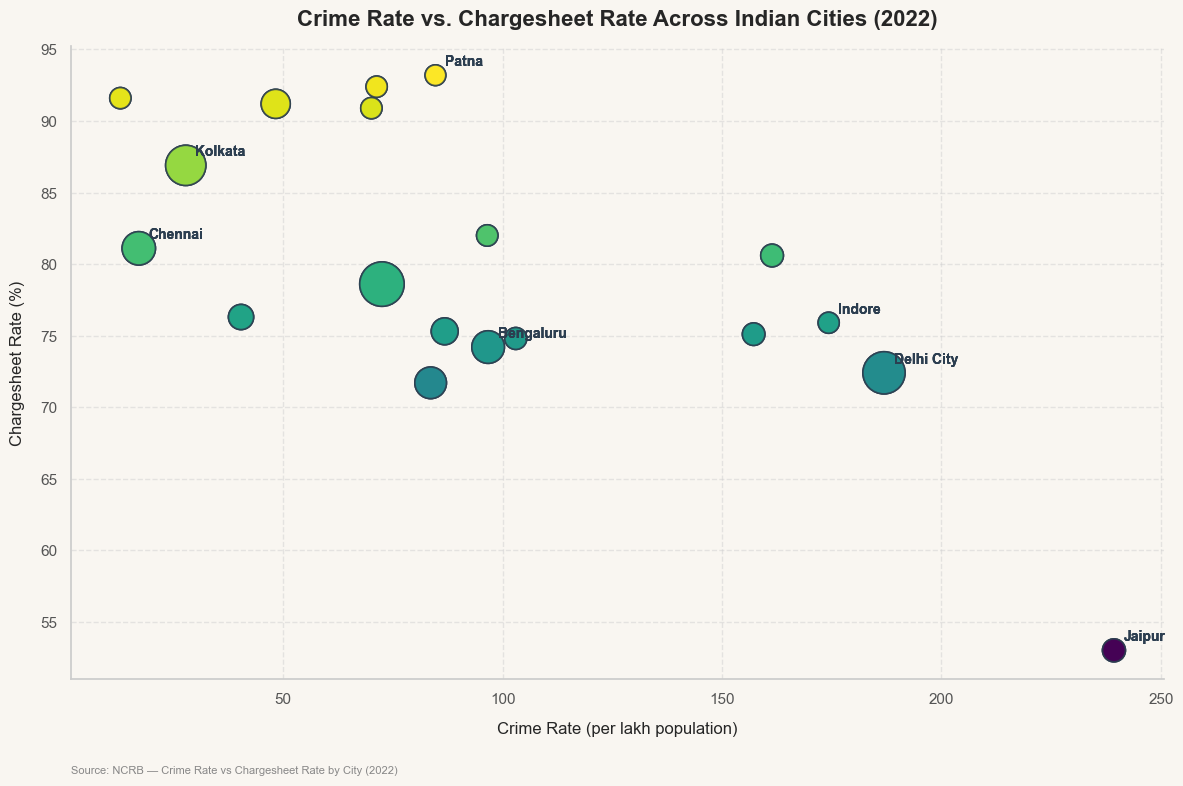

In [69]:
u.set_style()
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

latest_year = csv4["year"].max()
x = csv4["Rate of crime (%)"]
y = csv4["Chargesheet rate (%)"]
pop = csv4["Population as of 2011"]

sizes = (pop / pop.max()) * 900 + 120

scatter = ax.scatter(
    x,
    y,
    s=sizes,
    c=y,
    cmap="viridis",
    alpha=0.8,
    edgecolor="#2c3e50",
    linewidth=1.2,
)

for i, row in csv4.iterrows():
  city = row["Cities"]
  xi, yi = row["Rate of crime (%)"], row["Chargesheet rate (%)"]
  if city in [
      "Jaipur",
      "Indore",
      "Delhi City",
      "Patna",
      "Chennai",
      "Kolkata",
      "Bengaluru",
  ]:
    ax.annotate(
        city,
        xy=(xi, yi),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#2c3e50",
    )

ax.set_title(
    f"Crime Rate vs. Chargesheet Rate Across Indian Cities ({latest_year})",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Crime Rate (per lakh population)", fontsize=12)
ax.set_ylabel("Chargesheet Rate (%)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(
    ax,
    f"NCRB — Crime Rate vs Chargesheet Rate by City ({latest_year})",
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_01_crime_vs_chargesheet_bubblechart.png")
plt.show()

Chart saved- charts/csv4_02_city_crime_grouped_bargraph.png


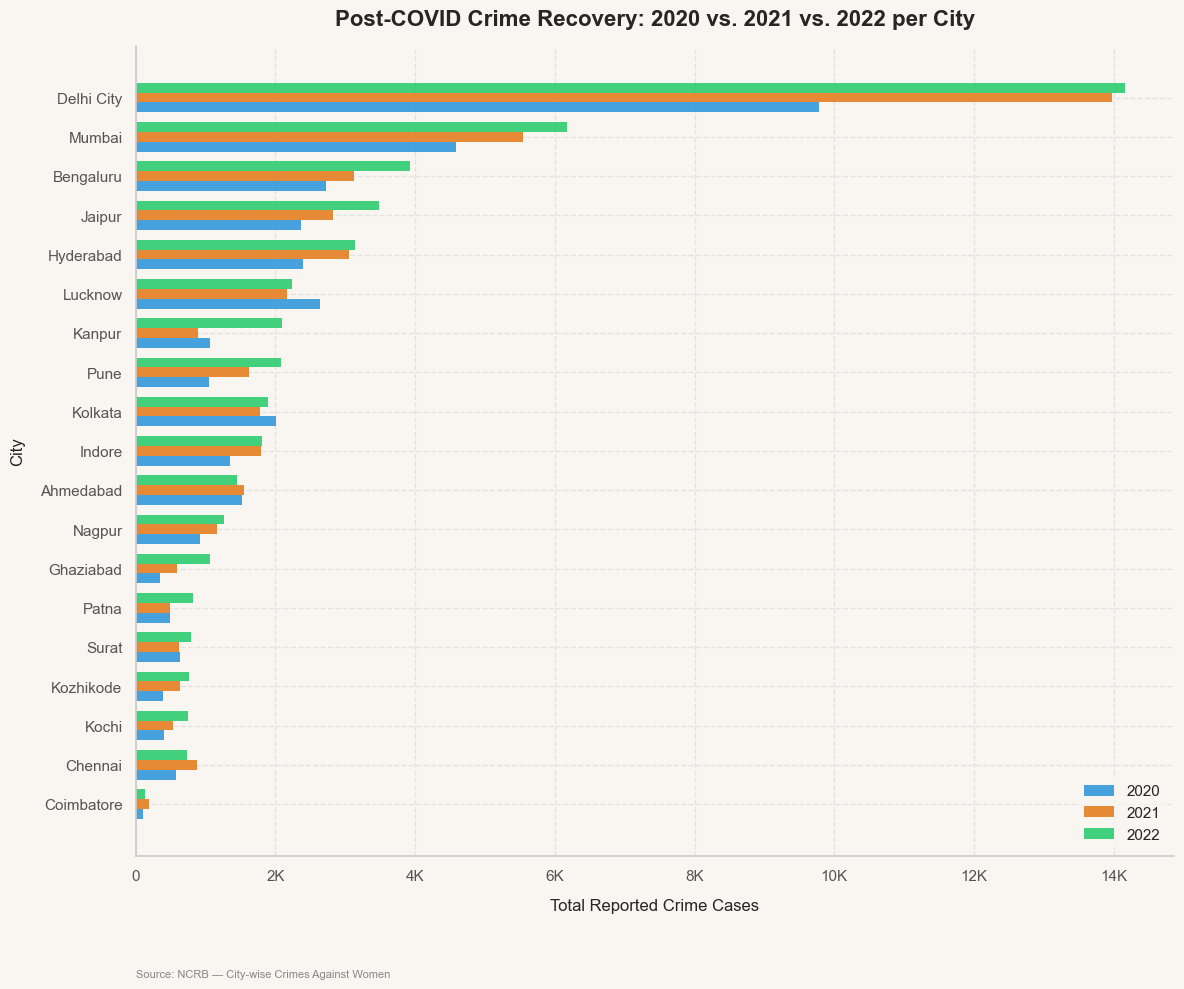

In [70]:
u.set_style()

pivot_df = csv4.pivot(
    index="Cities", columns="year", values="crime_cases"
).fillna(0)
pivot_df = pivot_df.sort_values(by=2022, ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = np.arange(len(pivot_df))
height = 0.25

ax.barh(
    y - height,
    pivot_df[2020],
    height,
    label="2020",
    color="#3498db",
    edgecolor="none",
    alpha=0.9,
)
ax.barh(
    y,
    pivot_df[2021],
    height,
    label="2021",
    color="#e67e22",
    edgecolor="none",
    alpha=0.9,
)
ax.barh(
    y + height,
    pivot_df[2022],
    height,
    label="2022",
    color="#2ecc71",
    edgecolor="none",
    alpha=0.9,
)

ax.set_yticks(y)
ax.set_yticklabels(pivot_df.index, fontsize=11)
ax.set_title(
    "Post-COVID Crime Recovery: 2020 vs. 2021 vs. 2022 per City",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Crime Cases", fontsize=12)
ax.set_ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)
ax.legend(
    frameon=True, facecolor=u.BG_COLOR, edgecolor="none", fontsize=11, loc="lower right"
)
ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(ax, "NCRB — City-wise Crimes Against Women")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_02_city_crime_grouped_bargraph.png")
plt.show()

Chart saved- charts/csv4_03_city_crime_rate_bargraph.png


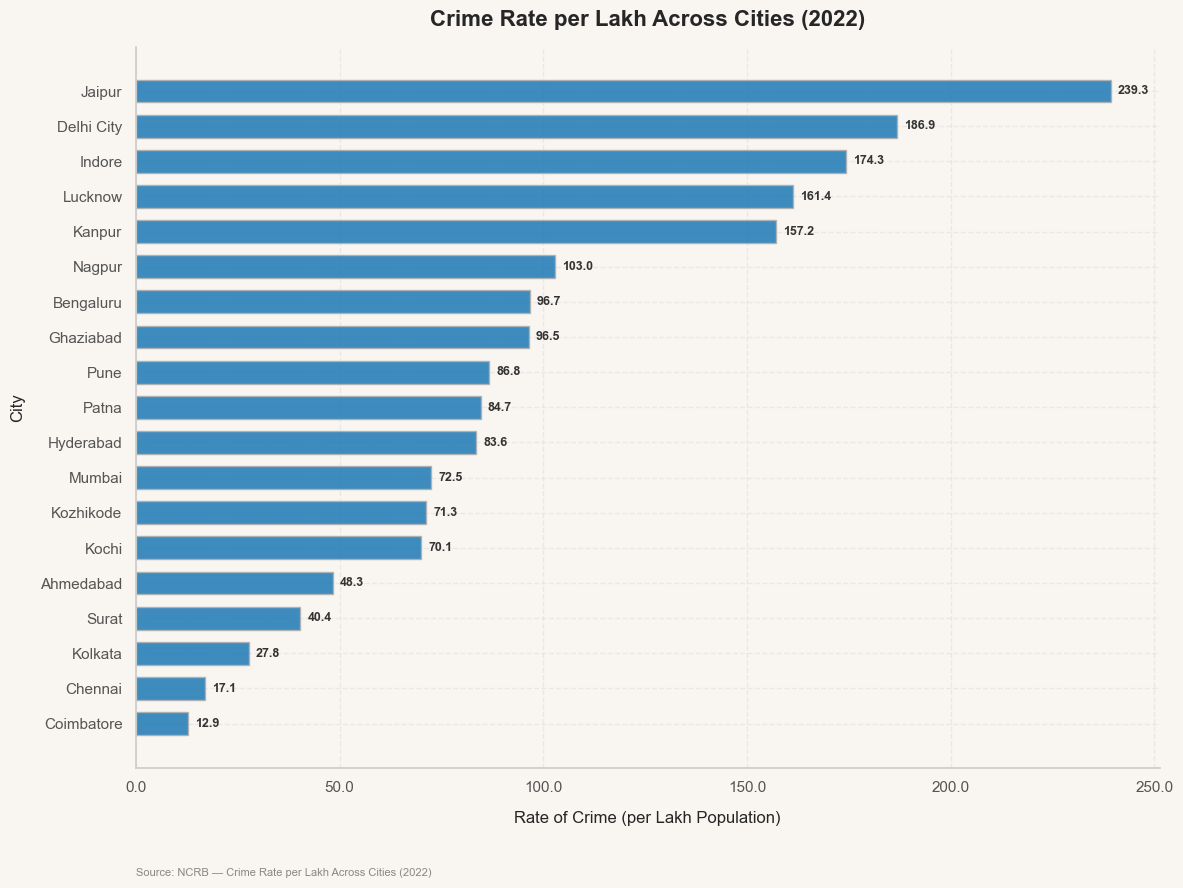

In [71]:
u.set_style()

csv4_2022 = csv4[csv4["year"] == 2022].copy()


# Sort by Rate of crime (%) ascending so lowest is at bottom, highest at top in barh
city_rates = csv4_2022.sort_values(by="Rate of crime (%)", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    city_rates["Cities"],
    city_rates["Rate of crime (%)"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Crime Rate per Lakh Across Cities (2022)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Rate of Crime (per Lakh Population)", fontsize=12)
ax.set_ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.1f}"))

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:.1f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crime Rate per Lakh Across Cities (2022)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_03_city_crime_rate_bargraph.png")
plt.show()

## e. csv7 Analysis

In [72]:
csv7.columns

Index(['Category', 'State/UT', 'Offense_Category', 'Offense_Subcategory',
       'Incidents'],
      dtype='object')

In [73]:
csv7['State/UT'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Andaman & Nicobar Islands',
       'Chandigarh', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Delhi',
       'Lakshadweep', 'Puducherry'], dtype=object)

Chart saved- charts/csv7_01_state_rape_cases_bar.png


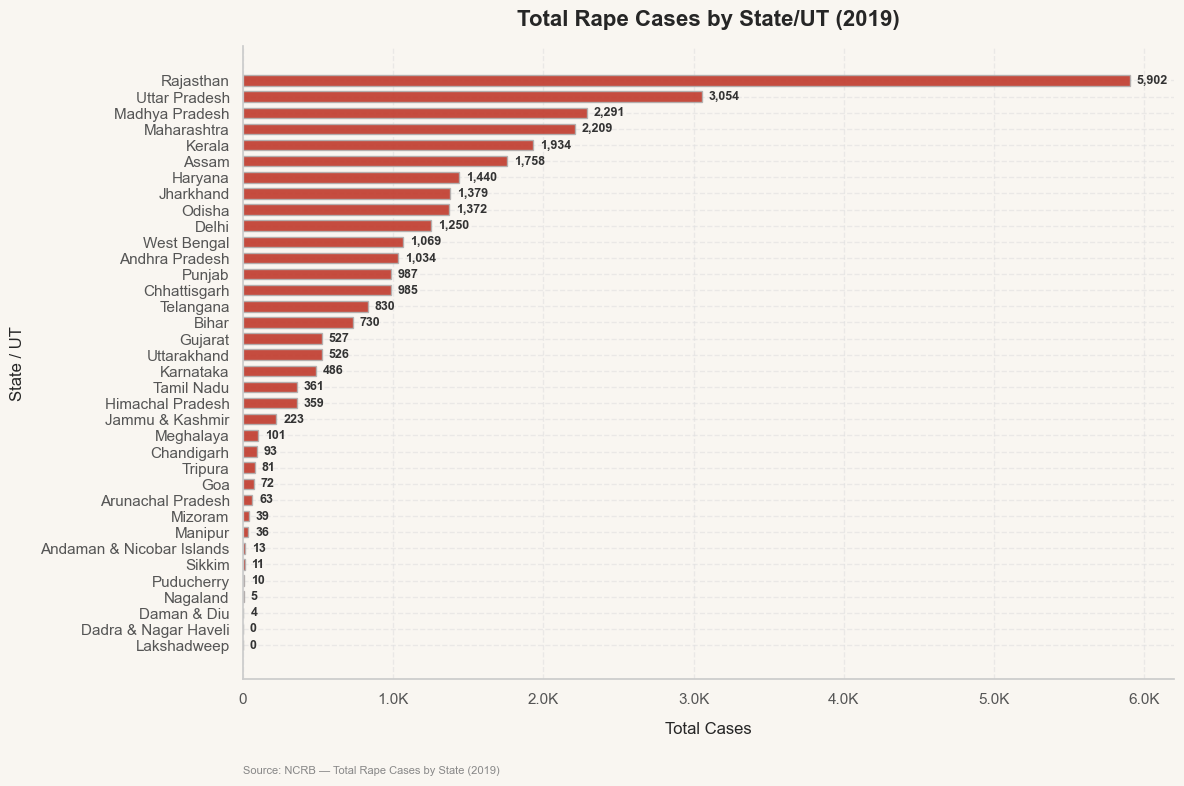

In [74]:
u.set_style()

# Group by State/UT to get total rape cases and sort for the horizontal bar
state_totals = (
    csv7.groupby("State/UT")["Incidents"]
    .sum()
    .sort_values(ascending=True)
)


fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

# Using a stark red to emphasize the severity of the data
bars = ax.barh(
    state_totals.index,
    state_totals.values,
    color="#c0392b",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Rape Cases by State/UT (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Cases", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1e3:.1f}K" if x >= 1e3 else f"{x:.0f}")
)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Total Rape Cases by State (2019)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_01_state_rape_cases_bar.png")
plt.show()

Chart saved- charts/csv7_02_rape_composition_stacked_bar.png


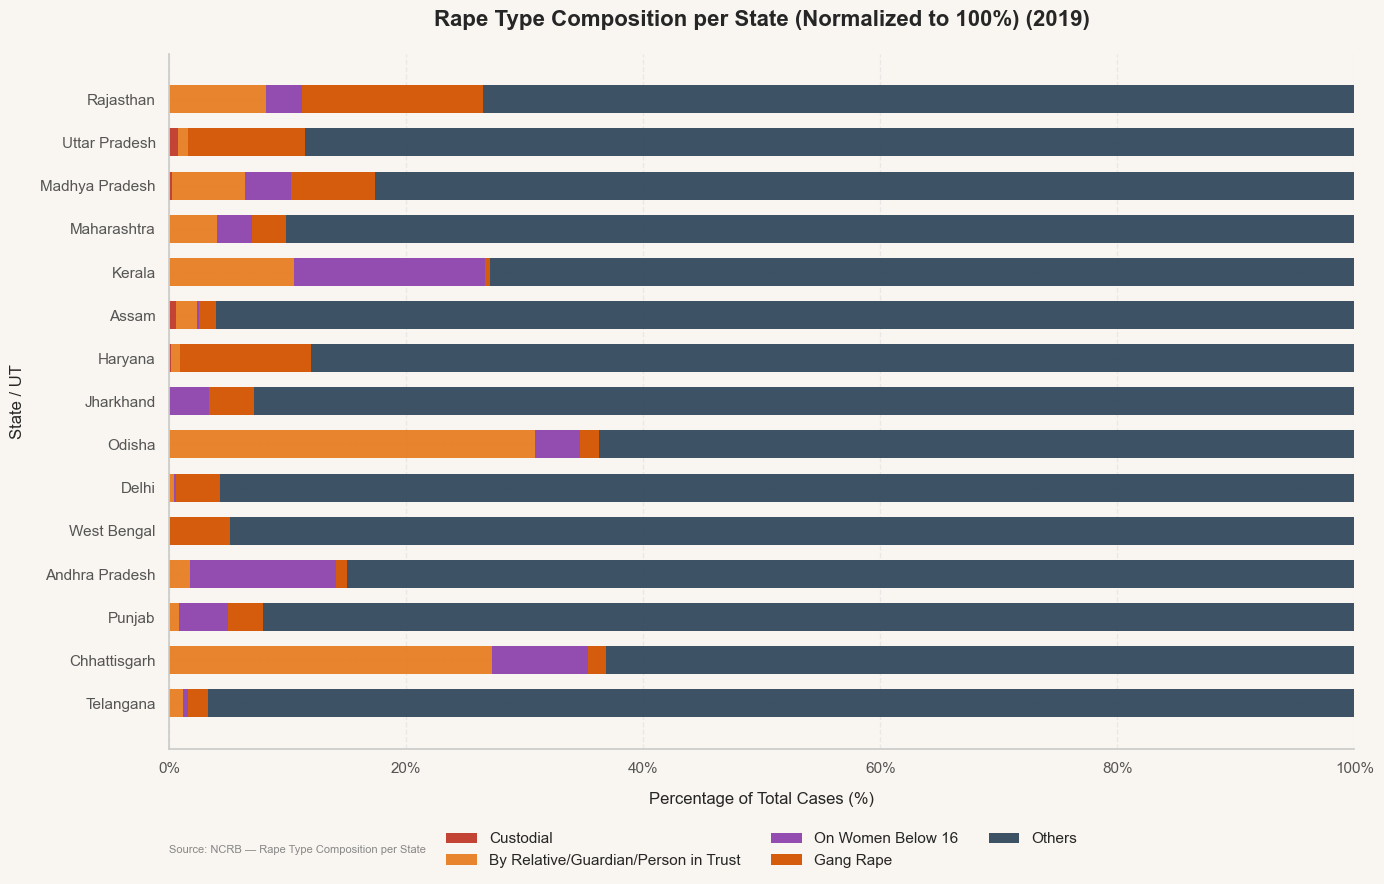

In [75]:
u.set_style()


# Function to map specific offense subcategories to requested types
def map_rape_category(row):
    cat = row["Offense_Category"]
    sub = row["Offense_Subcategory"]
    
    if cat == "Custodial":
        return "Custodial"
    elif sub == "Relative/Guardian/Teacher/person in position of trust":
        return "By Relative/Guardian/Person in Trust"
    elif "Below 16" in sub or "Below 12" in sub:
        return "On Women Below 16"
    elif sub == "Gang Incidents":
        return "Gang Rape"
    else:
        return "Others"

# Apply mapping
csv7["Rape_Type"] = csv7.apply(map_rape_category, axis=1)

# Aggregate incidents by State and Rape Type
csv7_pivot = csv7.pivot_table(
    index="State/UT", 
    columns="Rape_Type", 
    values="Incidents", 
    aggfunc="sum"
).fillna(0)

# Sort by total case volume and get the top 15 states for readability
state_totals = csv7_pivot.sum(axis=1).sort_values(ascending=True)
top_states = state_totals.tail(15).index
csv7_top15 = csv7_pivot.loc[top_states]

# Normalize to 100% per state
csv7_norm = csv7_top15.div(csv7_top15.sum(axis=1), axis=0) * 100

ordered_cols = [
    "Custodial", 
    "By Relative/Guardian/Person in Trust", 
    "On Women Below 16", 
    "Gang Rape", 
    "Others"
]

for col in ordered_cols:
    if col not in csv7_norm.columns:
        csv7_norm[col] = 0.0
csv7_norm = csv7_norm[ordered_cols]

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y_pos = np.arange(len(csv7_norm))
lefts = np.zeros(len(csv7_norm))

colors = {
    "Custodial": "#c0392b",                     # Dark Red
    "By Relative/Guardian/Person in Trust": "#e67e22", # Orange
    "On Women Below 16": "#8e44ad",             # Purple
    "Gang Rape": "#d35400",                     # Burnt Orange
    "Others": "#34495e"                         # Slate Blue/Grey
}

# Plot stacked horizontal bars
for col in ordered_cols:
    values = csv7_norm[col].values
    ax.barh(
        y_pos, 
        values, 
        left=lefts, 
        label=col, 
        color=colors[col], 
        height=0.65, 
        edgecolor="none", 
        alpha=0.95
    )
    lefts += values

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(csv7_norm.index, fontsize=11)
ax.set_xlim(0, 100)

ax.set_title(
    "Rape Type Composition per State (Normalized to 100%) (2019)", 
    fontsize=16, 
    fontweight="bold", 
    pad=20
)
ax.set_xlabel("Percentage of Total Cases (%)", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0f}%"))

ax.legend(
    loc="upper center", 
    bbox_to_anchor=(0.5, -0.1), 
    ncol=3, 
    frameon=False, 
    fontsize=11
)

u.add_source(ax, "NCRB — Rape Type Composition per State")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_02_rape_composition_stacked_bar.png")
plt.show()

Chart saved- charts/csv7_04_custodial_rape_subcategories.png


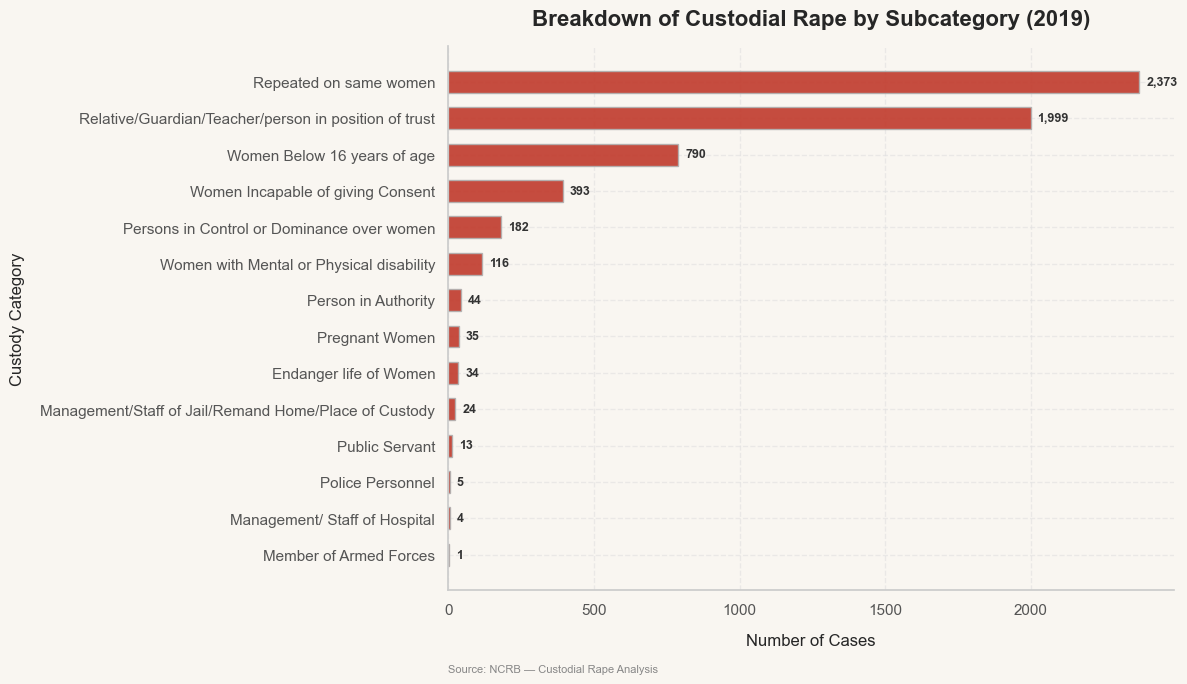

In [76]:
u.set_style()

# Filter for Custodial Rape records and aggregate by custody subcategories
custodial_df = csv7[csv7['Offense_Category'].str.contains("Custodial", case=False, na=False)]
subcat_totals = custodial_df.groupby('Offense_Subcategory')["Incidents"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    subcat_totals.index,
    subcat_totals.values,
    color="#c0392b",
    height=0.6,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Breakdown of Custodial Rape by Subcategory (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Cases", fontsize=12)
ax.set_ylabel("Custody Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Custodial Rape Analysis")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_04_custodial_rape_subcategories.png")
plt.show()

Chart saved- charts/csv7_05_UP_custodial_rape.png


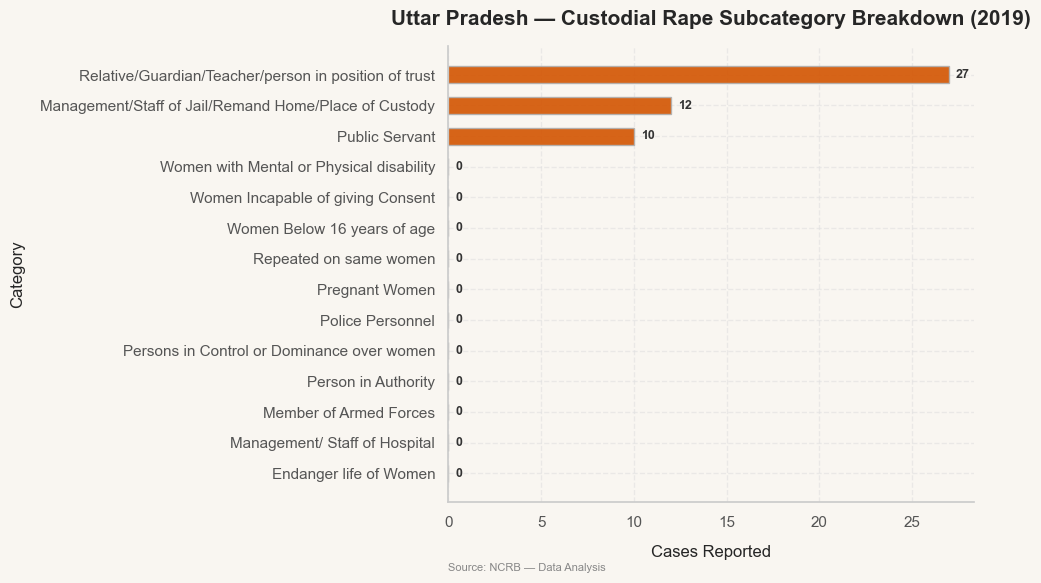

In [77]:
# Filter specifically for Uttar Pradesh custodial rape subcategories
up_custodial = csv7[
    (csv7["State/UT"].str.upper() == "UTTAR PRADESH") & 
    (csv7['Offense_Category'].str.contains("Custodial", case=False, na=False))
]

up_subcats = up_custodial.groupby("Offense_Subcategory")["Incidents"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    up_subcats.index,
    up_subcats.values,
    color="#d35400",
    height=0.55,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Uttar Pradesh — Custodial Rape Subcategory Breakdown (2019)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Cases Reported", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Data Analysis")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_05_UP_custodial_rape.png")
plt.show()

Chart saved- charts/csv7_06_minor_crimes_bar.png


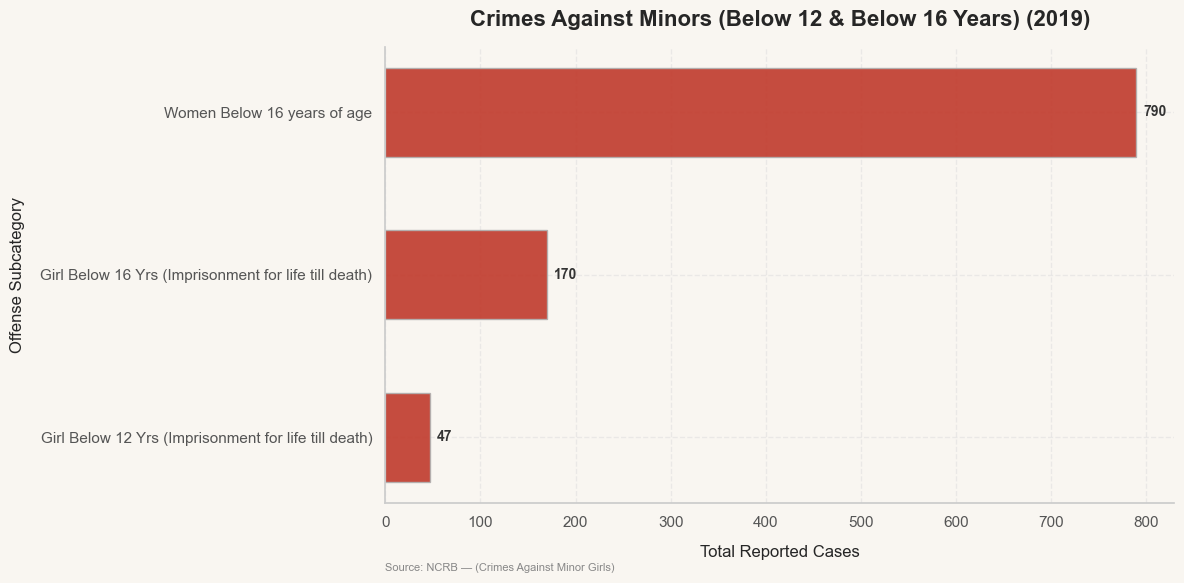

In [78]:
u.set_style()

# Filter specifically for minor protection offense subcategories
minor_categories = [
    "Girl Below 12 Yrs (Imprisonment for life till death)",
    "Girl Below 16 Yrs (Imprisonment for life till death)",
    "Women Below 16 years of age",
]

df_minors = csv7[csv7["Offense_Subcategory"].isin(minor_categories)]


# Aggregate total cases by offense category
category_totals = (
    df_minors.groupby("Offense_Subcategory")['Incidents']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    category_totals.index,
    category_totals.values,
    color="#c0392b",
    height=0.55,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Crimes Against Minors (Below 12 & Below 16 Years) (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Cases", fontsize=12)
ax.set_ylabel("Offense Subcategory", fontsize=12)

# X-axis number formatting
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:,.0f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=10,
      fontweight="bold",
      color="#333333",
  )

u.add_source(
    ax, "NCRB — (Crimes Against Minor Girls)"
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_06_minor_crimes_bar.png")
plt.show()

## f. csv5 Analysis

Chart saved- charts/csv5_01_arrest_to_conviction_pipeline.png


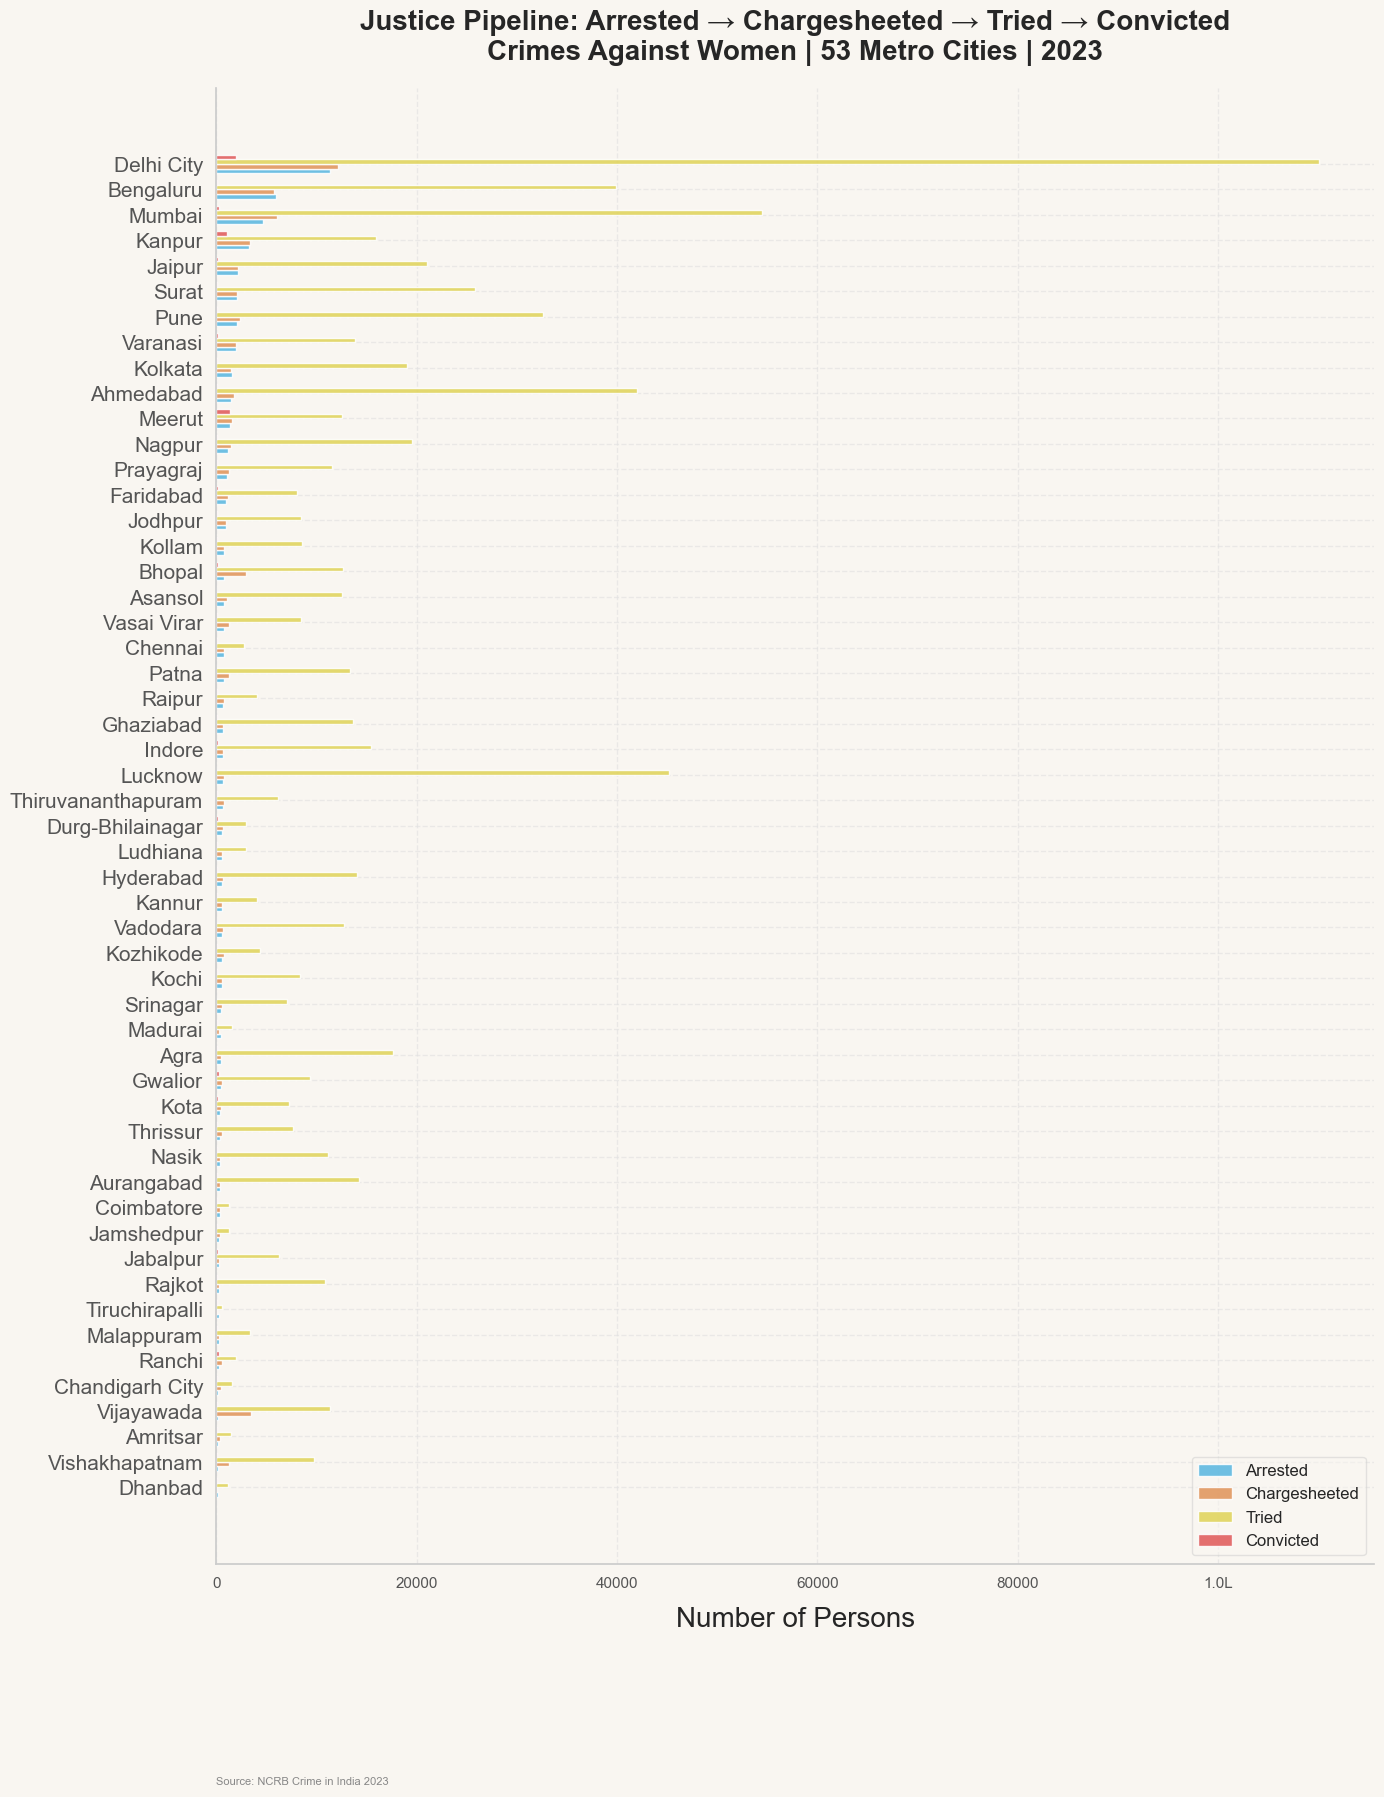

In [79]:
# Pipeline stages in logical order (both genders combined)
PIPELINE_STAGES = [
    "Persons Arrested in Cases Registered during the year",
    "Persons Arrested and Chargesheeted",
    "Persons in whose cases Trials were completed",
    "Persons Convicted",
]
STAGE_LABELS = ["Arrested", "Chargesheeted", "Tried", "Convicted"]
STAGE_COLORS = ["#5cb8e0", "#e0955c", "#e0d45c", "#e05c5c"]

# Aggregate both genders, keep only the 4 pipeline stages
pipe = (
    csv5[csv5["Crime"].isin(PIPELINE_STAGES)]
    .groupby(["city", "Crime"])["person_count"]
    .sum()
    .reset_index()
)
pipe["Stage"] = pipe["Crime"].map(dict(zip(PIPELINE_STAGES, STAGE_LABELS)))


pivot = (
    pipe.pivot(index="city", columns="Stage", values="person_count")
    [STAGE_LABELS]  
    .fillna(0)
    .sort_values("Arrested", ascending=True)   
)

u.set_style()
fig, ax = plt.subplots(figsize=(14, 18))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = range(len(pivot))
bar_h = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (stage, color) in enumerate(zip(STAGE_LABELS, STAGE_COLORS)):
    bars = ax.barh(
        [yi + offsets[i] * bar_h for yi in y],
        pivot[stage],
        height=bar_h,
        label=stage,
        color=color,
        alpha=0.88,
    )

ax.set_yticks(list(y))
ax.set_yticklabels(pivot.index, fontsize=15)
ax.set_xlabel("Number of Persons", fontsize=20)
ax.set_title(
    "Justice Pipeline: Arrested → Chargesheeted → Tried → Convicted\nCrimes Against Women | 53 Metro Cities | 2023",
    fontsize=20, fontweight="bold", pad=20
)
ax.legend(loc="lower right", fontsize=12, framealpha=0.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))
u.add_source(ax, "NCRB Crime in India 2023")
plt.tight_layout()

u.save_fig(fig, "charts", "csv5_01_arrest_to_conviction_pipeline.png")
plt.show()